# Import Libraries

In [1]:
import os
import dill
import numpy as np
import sys
import pathlib
import pandas as pd
import pickle
import time
from collections import defaultdict

import scipy.special

# importing modules/libs for plotting
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.express as px
# from plotly.offline import plot
import plotly.offline as pyo  # plot
# Set notebook mode to work in offline
pyo.init_notebook_mode()
import matplotlib.pyplot as plt  # mp

pd.options.plotting.backend = "plotly"

In [2]:
import chaospy as cp
# import uqef
print(cp.__version__)

4.3.20


In [3]:
from uqef_dynamic.utils import utility
from uqef_dynamic.utils import uqef_dynamic_utils
from uqef_dynamic.models.hbv_sask import hbvsask_utility as hbv
from uqef_dynamic.models.hbv_sask import HBVSASKModel as hbvmodel
from uqef_dynamic.models.hbv_sask import HBVSASKStatistics as HBVSASKStatistics
from uqef_dynamic.utils import create_stat_object


MPI version: Open MPI v5.0.10, package: Open MPI runner@sjc20-av647-db3ce1ac-0006-43d3-8969-390c10a63297-12DDBC26DBF0.local Distribution, ident: 5.0.10, repo rev: v5.0.10, Feb 23, 2026 
MPI2 version: (3, 1)
MPI3 version: 3
mpi4py version: 4.1.1
rank 0: starttime: 2026.09.11 14:58:36


In [4]:
COLORS = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
    '#637939', '#393b79', '#8c6d31', '#843c39', '#7b4173',
    '#3182bd', '#6baed6', '#9ecae1', '#c6dbef', '#e6550d',
    '#fd8d3c', '#fdae6b', '#fdd0a2', '#31a354', '#74c476',
    '#a1d99b', '#c7e9c0', '#756bb1', '#9e9ac8', '#bcbddc'
]
PARAMETERS = ["TT", "C0", "ETF", "FC", "beta", "FRAC", "K2", "LP", "K1", "alpha", "PM"]
COLORS_DICT = {PARAMETERS[idx]:COLORS[idx] for idx in range(len(PARAMETERS))}
COLORS_DICT

{'TT': '#1f77b4',
 'C0': '#ff7f0e',
 'ETF': '#2ca02c',
 'FC': '#d62728',
 'beta': '#9467bd',
 'FRAC': '#8c564b',
 'K2': '#e377c2',
 'LP': '#7f7f7f',
 'K1': '#bcbd22',
 'alpha': '#17becf',
 'PM': '#637939'}

# Running the model - whole timespan and unchanged parameter values

In [ ]:
basin = "Oldman_Basin"

# hbv_model_data_path = pathlib.Path("/work/ga45met/Hydro_Models/HBV-SASK-data")
# inputModelDir = hbv_model_data_path
# workingDir = hbv_model_data_path / basin / "model_runs" / 'run_full'

BASE_SOURCE_PATH = pathlib.Path.cwd().parents[0] # UQEF-Dynamic root
print(BASE_SOURCE_PATH)
hbv_model_data_path = BASE_SOURCE_PATH / "data" / "HBV-SASK-data"
print(f"hbv_model_data_path-{hbv_model_data_path}")
inputModelDir = hbv_model_data_path
basis_workingDir = hbv_model_data_path / "paper_uqef_dynamic_sim"
workingDir = basis_workingDir / 'run_full'

# with open(configurationObject) as f:
#     configurationObject = json.load(f)
configurationObject = {
    "time_settings":
    {
      "run_full_timespan":"True",
      "resolution": "daily",
    },
  "model_settings":
    {
    "basin": "Oldman_Basin",
  },
  "simulation_settings": {
    "qoi":["Q_cms","AET"],
    "qoi_column":["Q_cms","AET"],
    # "transform_model_output":["log", "None"],
    "transform_model_output":["None", "None"],
    "read_measured_data": ["True","False"],
    "qoi_column_measured":["streamflow","None"],
    "autoregressive_model_first_order":"False",
    "calculate_GoF":"True",
    "objective_function":["MAE", "MSE", "RMSE", "NRMSE", "NSE", "LogNSE", "KGE"],
    "mode":"continuous",
  }
}    

writing_results_to_a_file = True
plotting = True
createNewFolder = True # create a separate folder to save results for each model run

hbvsaskModelObject = hbvmodel.HBVSASKModel(
    configurationObject=configurationObject,
    inputModelDir=inputModelDir,
    workingDir=workingDir,
    basin=basin,
    writing_results_to_a_file=writing_results_to_a_file,
    plotting=plotting
)

# get to know some of the relevant time settings, read from a json configuration file
print(f"start_date: {hbvsaskModelObject.start_date}")
print(f"start_date_predictions: {hbvsaskModelObject.start_date_predictions}")
print(f"end_date: {hbvsaskModelObject.end_date}")
print(f"full_data_range is {len(hbvsaskModelObject.full_data_range)} days including spin_up_length of {hbvsaskModelObject.spin_up_length} days")
print(f"simulation_range is of length {len(hbvsaskModelObject.simulation_range)} days")

In [ ]:
start = time.time()
results_array = hbvsaskModelObject.run(createNewFolder=createNewFolder)
end = time.time()
runtime = end - start
print(f"single execution of the model's run function take {runtime}; \
full_data_range is {len(hbvsaskModelObject.full_data_range)} days including spin_up_length of {hbvsaskModelObject.spin_up_length} days")

In [ ]:
results_array[0][0]['result_time_series']

In [ ]:
hbvsaskModelObject.time_series_measured_data_df

In [ ]:
print(results_array[0][0].keys())
print(f"runtime:{results_array[0][0]['run_time']}\n")
print(f"parameters dict:{results_array[0][0]['parameters_dict']}\n")
print(f"GoF DF:{results_array[0][0]['gof_df']}")

In [ ]:
fig = hbv.plot_streamflow_and_precipitation(
    input_data_df=hbvsaskModelObject.time_series_measured_data_df, 
    simulated_data_df=results_array[0][0]['result_time_series'], 
    input_data_time_column=hbvsaskModelObject.time_column_name,
    simulated_time_column=hbvsaskModelObject.time_column_name, 
    observed_streamflow_column=hbvsaskModelObject.streamflow_column_name,
    simulated_streamflow_column="Q_cms", 
    precipitation_columns=hbvsaskModelObject.precipitation_column_name)
fig.show()

In [ ]:
for each_computed_gof in ["MAE", "MSE", "RMSE", "NRMSE", "NSE", "LogNSE", "KGE"]:
    if each_computed_gof in results_array[0][0]['gof_df'].columns:
        print(f"{each_computed_gof}:{results_array[0][0]['gof_df'][each_computed_gof].values}")

In [ ]:
state_df = results_array[0][0]['state_df']
state_df.columns

# Running the model - whole timespan and changed parameter values

In [ ]:
parameter_value_dict_1 = {'TT': 0.0, 'C0': 0.5, 'ETF': 0.2, 'FC': 250, 'FRAC': 0.1, 'K2': 0.025, 'K1': 0.5, 'alpha':2.0}
parameter_value_dict_2 = {'TT': 0.0, 'C0': 0.5, 'ETF': 0.2, 'FC': 250, 'FRAC': 0.3, 'K2': 0.025, 'K1': 0.5, 'alpha':2.0}
parameter_value_dict_3 = {'TT': 0.0, 'C0': 0.5, 'ETF': 0.2, 'FC': 250, 'FRAC': 0.1, 'K2': 0.05, 'K1': 0.5, 'alpha':2.0}
parameter_value_dict_4 = {'TT': 0.0, 'C0': 0.5, 'ETF': 0.2, 'FC': 250, 'FRAC': 0.1, 'K2': 0.1, 'K1': 0.5, 'alpha':2.0}
parameter_value_dict_5 = {'TT': -4.0, 'C0': 5.0, 'ETF': 0.5, 'FC': 50, 'FRAC': 0.1, 'K2': 0.025, 'K1': 0.5, 'alpha':2.0}
parameter_value_dict_6 = {'TT': 0.5, 'C0': 2.0, 'ETF': 0.5, 'FC': 350, 'FRAC': 0.2, 'K2': 0.05, 'K1': 0.5, 'alpha':2.0}
parameter_value_dict = {'TT': 0.0, 'C0': 0.5, 'ETF': 0.2, 'FC': 250, 'FRAC': 0.3, 'K2': 0.05, 'K1': 0.5, 'alpha':2.0}

createNewFolder = True
writing_results_to_a_file = True

unique_run_index = [1, 2, 3, 4, 5, 6, 7]
list_of_parameters = [
    parameter_value_dict_1, parameter_value_dict_2, parameter_value_dict_3, parameter_value_dict_4, parameter_value_dict_5, 
    parameter_value_dict_6, parameter_value_dict
]
start = time.time()
results_array_changed_param = hbvsaskModelObject.run(
    parameters = list_of_parameters,
    i_s = unique_run_index,
    createNewFolder=createNewFolder,
    take_direct_value=True,
    writing_results_to_a_file=writing_results_to_a_file,
)
end = time.time()
runtime = end - start
print(f"execution of the {len(unique_run_index)} model's run function take {runtime}; full_data_range is {len(hbvsaskModelObject.full_data_range)} days including spin_up_length of {hbvsaskModelObject.spin_up_length} days")

In [ ]:
fig = go.Figure()
for indx in range(0, len(results_array_changed_param)):
    temp = results_array_changed_param[indx][0]['result_time_series']
    fig.add_trace(
        go.Scatter(
            x=temp.index,y=temp["Q_cms"], 
            name=repr(results_array_changed_param[indx][0]['parameters_dict']),
        )
    )
fig.update_layout(
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1.0),
    showlegend=True,
    # template="plotly_white",
)
fig.show()

In [ ]:
for indx in range(0, len(results_array_changed_param)):
    print(results_array_changed_param[indx][0]['gof_df'])
    

### Extracting error signal for each run...

In [ ]:
hbvsaskModelObject.time_series_measured_data_df

In [ ]:
fig = go.Figure()

qoi_column = "Q_cms"
series_list = []
index_values = []
for indx in range(0, len(results_array_changed_param)):
    error_signal =\
    results_array_changed_param[indx][0]['result_time_series'][qoi_column] - hbvsaskModelObject.time_series_measured_data_df[hbvsaskModelObject.streamflow_column_name]
    series_list.append(error_signal)
    index_values.append(indx)

    fig.add_trace(
        go.Scatter(
            x=error_signal.index,y=error_signal, 
            name=indx,
        )
    )

# each Series becomes one row
# df = pd.DataFrame(series_list)
# concat vertically with a key for each run
combined = pd.concat(series_list, keys=index_values)
df_error = (
    combined.rename(qoi_column)                 # name the data column
            .rename_axis([utility.INDEX_COLUMN_NAME, utility.TIME_COLUMN_NAME])  # name the index levels
            .reset_index()                  # turn both indices into columns
)
# df_error
fig.show()

In [ ]:
fig = go.Figure()

grouped = df_error.groupby(utility.INDEX_COLUMN_NAME)
groups = grouped.groups
keyIter = list(groups.keys())

for key in keyIter:
    df_error_subset = df_error.loc[groups[key].values]
    # df_error_subset = df_error_subset.sort_values(by=utility.TIME_COLUMN_NAME)
    fig.add_trace(
        go.Scatter(
            x=df_error_subset[utility.TIME_COLUMN_NAME], 
            y=df_error_subset[qoi_column],
            # mode="lines", 
            # line_color='LightSkyBlue', opacity=0.3, showlegend=False,
        )
    )
fig.update_layout(
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1.0),
    showlegend=True,
    # template="plotly_white",
)
fig.show()

# Reading Ensemble Data from Cluster Runs

# Defining paths

In [5]:
# TODO - change these paths accordingly
BASE_SOURCE_PATH = pathlib.Path.cwd().parents[0] # UQEF-Dynamic root
hbv_model_data_path = BASE_SOURCE_PATH / "data" / "HBV-SASK-data"
inputModelDir = hbv_model_data_path

basis_workingDir = pathlib.Path('/work/ga45met/paper_uqef_dynamic_sim/hbvsask_runs_lxc_autumn_24')
basis_workingDir = hbv_model_data_path / "paper_uqef_dynamic_sim"

# Oldman, whole time span, ensemble analysis
workingDir = basis_workingDir / 'hbv_uq_cm4.0316'

# Oldman, 3 years, ensemble analysis
workingDir = basis_workingDir / 'hbv_uq_cm4.0328'
directory_for_saving_plots = pathlib.Path('/work/ga45met/paper_uqef_dynamic_sim/hbv_sask/oldman_2004_2007/oldman_2004_2007_ensemble/')

# Banff, 6 years, ensemble analysis
# workingDir = basis_workingDir / 'hbv_uq_cm4.0327'
# directory_for_saving_plots = pathlib.Path('/work/ga45met/paper_uqef_dynamic_sim/hbv_sask/banff_2004_2010/banff_2004_2010_ensemble/')

directory_for_saving_plots = workingDir
directory_for_saving_plots = hbv_model_data_path / "oldman_2004_2007_post_analysis_output"

workingDir = basis_workingDir / 'hbv_uq_cm4.0332'
directory_for_saving_plots = workingDir

if not str(directory_for_saving_plots).endswith("/"):
    directory_for_saving_plots = str(directory_for_saving_plots) + "/"
directory_for_saving_plots =  pathlib.Path(directory_for_saving_plots)


# Reading Saved Files, i.e., Input Arguments and Configuration

In [6]:
args_files = utility.get_dict_with_output_file_paths_based_on_workingDir(
    workingDir,
    # df_index_parameter_file="df_all_index_parameter_values.pkl",
    # df_index_parameter_gof_file="df_all_index_parameter_gof_values.pkl",
)

for key, value in args_files.items():
    globals()[key] = value

In [7]:
with open(args_file, 'rb') as f:
    uqsim_args = pickle.load(f)
uqsim_args_dict = vars(uqsim_args)
uqsim_args_dict

{'smoketest': False,
 'uqsim_file': 'uqsim.saved',
 'uqsim_store_to_file': False,
 'uqsim_restore_from_file': False,
 'disable_calc_statistics': False,
 'disable_recalc_statistics': False,
 'disable_statistics': False,
 'inputModelDir': '/dss/dssfs02/lwp-dss-0001/pr63so/pr63so-dss-0000/ga45met2/HBV-SASK-data',
 'outputModelDir': '.',
 'outputResultDir': '/dss/dssfs02/lwp-dss-0001/pr63so/pr63so-dss-0000/ga45met2/hbvsask_runs/hbv_uq_cm4.0332',
 'sourceDir': '/dss/dsshome1/lxc0C/ga45met2/Repositories/UQEF-Dynamic',
 'model': 'hbvsask',
 'model_variant': 1,
 'simulate_wait': False,
 'uncertain': 'all',
 'uq_method': 'mc',
 'regression': False,
 'mc_numevaluations': 500000,
 'sc_q_order': 6,
 'sc_p_order': 4,
 'sc_sparse_quadrature': False,
 'sc_quadrature_rule': 'p',
 'sc_poly_normed': False,
 'sc_poly_rule': 'three_terms_recurrence',
 'cross_truncation': 0.7,
 'regression_model_type': None,
 'sampling_rule': 'random',
 'transformToStandardDist': False,
 'sampleFromStandardDist': True,
 'c

In [8]:
model = uqsim_args_dict['model']
model

'hbvsask'

In [9]:
time_info_file
if time_info_file.is_file():
    with open(time_info_file, 'r') as f:
        time_info = f.read() #readlines()?
        print("INFO: time_info: ", time_info)

INFO: time_info:  number_full_model_runs: 500000
time_model_simulations: 4892.437735795975
time_computing_statistics: 609.9856882095337
total_time: 5510.4098381996155



In [10]:
print(configuration_object_file)
with open(configuration_object_file, 'rb') as f:
    configurationObject = dill.load(f)
configurationObject

/Users/katarinagrcic/Documents/Ivana_Phd/UQEF-Dynamic/data/HBV-SASK-data/paper_uqef_dynamic_sim/hbv_uq_cm4.0332/configurationObject


{'time_settings': {'start_day': 1,
  'start_month': 10,
  'start_year': 2001,
  'start_hour': 0,
  'start_minute': 0,
  'end_day': 1,
  'end_month': 10,
  'end_year': 2007,
  'end_hour': 0,
  'end_minute': 0,
  'run_full_timespan': 'False',
  'spin_up_length': 1096,
  'simulation_length': 1095,
  'resolution': 'daily',
  'cut_runs': 'False',
  'timestep': 5},
 'model_settings': {'basin': 'Banff_Basin',
  'plotting': 'False',
  'writing_results_to_a_file': 'False',
  'corrupt_forcing_data': 'False'},
 'model_paths': {'hbv_model_path': 'Hydro_Models/HBV-SASK-data',
  'workingDir': '/dss/dssfs02/lwp-dss-0001/pr63so/pr63so-dss-0000/ga45met2/hbvsask_runs/hbv_uq_cm4.0332'},
 'simulation_settings': {'qoi': ['Q_cms', 'AET'],
  'qoi_column': ['Q_cms', 'AET'],
  'transform_model_output': [None, None],
  'read_measured_data': ['True', 'False'],
  'qoi_column_measured': ['streamflow', None],
  'autoregressive_model_first_order': 'False',
  'scale_factor_autoregressive_model_first_order': 0.9,
  'o

In [11]:
basin = configurationObject['model_settings']['basin']
print(f"basin {basin}")

basin Banff_Basin


In [12]:
simulation_settings_dict = utility.read_simulation_settings_from_configuration_object(configurationObject)
simulation_settings_dict


{'qoi': ['Q_cms', 'AET'],
 'qoi_column': ['Q_cms', 'AET'],
 'multiple_qoi': True,
 'number_of_qois': 2,
 'autoregressive_model_first_order': False,
 'scale_factor_autoregressive_model_first_order': 0.9,
 'transform_model_output': [None, None],
 'qoi_column_measured': ['streamflow', None],
 'read_measured_data': [True, False],
 'calculate_GoF': True,
 'list_calculate_GoF': [True, False],
 'objective_function': ['MAE', 'MSE', 'RMSE', 'NRMSE', 'NSE', 'LogNSE', 'KGE'],
 'objective_function_qoi': None,
 'objective_function_names_qoi': None,
 'list_objective_function_qoi': None,
 'list_objective_function_names_qoi': None,
 'list_qoi_column': ['Q_cms', 'AET'],
 'list_qoi_column_measured': ['streamflow', None],
 'list_read_measured_data': [True, False],
 'list_transform_model_output': [None, None],
 'dict_qoi_column_and_measured_info': defaultdict(tuple,
             {'Q_cms': (True, 'streamflow', None),
              'AET': (False, None, None)}),
 'mode': 'continuous',
 'method': 'avrg',
 'in

#### extra anlyzing

In [13]:
# Number of uncertain parameters
len(configurationObject["parameters"])

7

In [14]:
# Quantity of Interes
print(configurationObject["simulation_settings"]["qoi"])
print(configurationObject["simulation_settings"]["qoi_column"])

['Q_cms', 'AET']
['Q_cms', 'AET']


# Reading Nodes and Parameters

In [15]:
with open(nodes_file, 'rb') as f:
#     simulationNodes = dill.load(f)
    simulationNodes = pickle.load(f)
simulationNodes

print(simulationNodes.nodes.shape)
print(simulationNodes.parameters.shape)

(7, 500000)
(7, 500000)


#### extra anlyzing

In [ ]:
simulationNodes.nodes

In [ ]:
simulationNodes.nodes.shape

In [ ]:
simulationNodes.parameters

In [ ]:
simulationNodes.parameters.shape

In [ ]:
simulationNodes.joinedDists

In [ ]:
simulationNodes.joinedStandardDists

# Reading Parameters and GoF Computed Data

In [17]:
df_index_parameter_file

PosixPath('/Users/katarinagrcic/Documents/Ivana_Phd/UQEF-Dynamic/data/HBV-SASK-data/paper_uqef_dynamic_sim/hbv_uq_cm4.0332/df_index_parameter.pkl')

In [18]:
df_uqsim_simulation_parameters_file = workingDir / 'df_uqsim_simulation_parameters.pkl'
if df_uqsim_simulation_parameters_file.is_file():
    df_uqsim_simulation_parameters = pd.read_pickle(df_uqsim_simulation_parameters_file, compression="gzip")
else:
    df_uqsim_simulation_parameters = None
df_uqsim_simulation_parameters

In [19]:
if df_index_parameter_file.is_file():
    df_index_parameter = pd.read_pickle(df_index_parameter_file, compression="gzip")
else:
    df_index_parameter = None
df_index_parameter

In [20]:
if df_index_parameter is not None:
    params_list = utility._get_parameter_columns_df_index_parameter_gof(
        df_index_parameter)
else:
    params_list = []
    for single_param in configurationObject["parameters"]:
        params_list.append(single_param["name"])
params_list

['TT', 'C0', 'ETF', 'FC', 'FRAC', 'K2', 'PM']

In [21]:
if df_index_parameter_gof_file.is_file():
    df_index_parameter_gof = pd.read_pickle(df_index_parameter_gof_file, compression="gzip")
    df_index_parameter_gof
else:
    print(f"Be careful - {df_index_parameter_gof_file} does not exist!")
    df_index_parameter_gof = None
df_index_parameter_gof

Be careful - /Users/katarinagrcic/Documents/Ivana_Phd/UQEF-Dynamic/data/HBV-SASK-data/paper_uqef_dynamic_sim/hbv_uq_cm4.0332/df_index_parameter_gof.pkl does not exist!


In [22]:
if df_index_parameter_gof is not None:
    gof_list = utility._get_gof_columns_df_index_parameter_gof(
        df_index_parameter_gof)
else:
    gof_list = None
    print(f"Be careful - {df_index_parameter_gof_file} does not exist - therefore gof_list is not populated!")
gof_list

['MAE', 'MSE', 'RMSE', 'NRMSE', 'NSE', 'LogNSE', 'KGE']

### In case there was some conditioning

In [ ]:
# In case there was some conditioning...
df_index_parameter_file = workingDir / utility.DF_INDEX_PARAMETER_CONDITIONED_FILE
if df_index_parameter_file.is_file():
    df_index_parameter_conditioned = pd.read_pickle(df_index_parameter_file, compression="gzip")
else:
    df_index_parameter_conditioned = None
df_index_parameter_conditioned

In [ ]:
# In case there was some conditioning...
df_index_parameter_gof_file = workingDir / utility.DF_INDEX_PARAMETER_GOF_CONDITIONED_FILE
if df_index_parameter_gof_file.is_file():
    df_index_parameter_gof_condtioned = pd.read_pickle(df_index_parameter_gof_file, compression="gzip")
else:
    df_index_parameter_gof_condtioned = None
df_index_parameter_gof_condtioned

## Extra anlyzing & plotting (parameters and GoF)

In [23]:
df_index_parameter_gof[gof_list].describe(include=np.number)

,MAE,MSE,RMSE,NRMSE,NSE,LogNSE,KGE
count,177147.000000,177147.000000,177147.000000,177147.000000,177147.000000,177147.000000,177147.000000
mean,16.225444,1461.843152,32.243816,0.089566,-1.650727,-15.843402,-0.361623
std,8.279002,2457.464336,20.547064,0.057075,4.456065,23.053260,0.898757
min,4.284735,90.724112,9.524921,0.026458,-35.299122,-148.644821,-4.782851
25%,11.494697,478.335604,21.870885,0.060752,-0.910109,-20.698616,-0.466986
50%,13.429139,638.143154,25.261495,0.070171,-0.157131,-5.481734,-0.174781
75%,16.546672,1053.401160,32.456142,0.090156,0.132645,-1.565289,0.176872
max,47.721468,20018.513895,141.486798,0.393019,0.835492,0.707943,0.906457


In [ ]:
fig = utility.plot_2d_matrix_static_from_list(df_index_parameter[params_list], title="Plot 2D projected positions of the nodes")
filename = directory_for_saving_plots / "pairplot_simulation_nodes.pdf"
fig.savefig(str(filename), format="pdf")

In [ ]:
fig  = utility.plot_scatter_matrix_params_vs_gof(
    df_index_parameter_gof, columns_with_parameters=None, name_of_gof_column="KGE", hover_name="Index_run",
    height=800, width=800, title=None, color_continuous_scale='Viridis', diagonal_visible=False)
fig.show()

In [ ]:
fig  = utility.plot_scatter_matrix_params_vs_gof_lower_triangular(
    df_index_parameter_gof, columns_with_parameters=None, name_of_gof_column="NSE", hover_name="Index_run",
    height=800, width=800, title=None, color_continuous_scale='Viridis', diagonal_visible=False)
fig.show()

In [ ]:
# This is also possible to call/use
fig = utility.plot_scatter_matrix_params_vs_gof_seaborn(df_index_parameter_gof)
fig.show()

In [ ]:
# one can as well call uqef_dynamic_utils.gof_values_GaussianKDE to produce this plot

fig, axs = plt.subplots(1, len(gof_list), figsize=(20, 10))

for i in range(len(gof_list)):
    single_gof = gof_list[i]
    min_single_gof = df_index_parameter_gof[single_gof].min() - abs(df_index_parameter_gof[single_gof].min())*0.001
    max_single_gof = df_index_parameter_gof[single_gof].max() + abs(df_index_parameter_gof[single_gof].max())*0.001
    t = np.linspace(min_single_gof, max_single_gof, 1000)
    gof_eval = df_index_parameter_gof[single_gof].values
    distribution = cp.GaussianKDE(gof_eval, h_mat=0.005 ** 2)
    axs[i,].hist(gof_eval, bins=100, density=True, alpha=0.5)
    axs[i,].plot(t, distribution.pdf(t), label=f"KDE {single_gof}")
    plt.setp(axs[i,], xlabel=f'{single_gof}')
    axs[i,].grid()
plt.setp(axs[0], ylabel='PDF')
# fig.suptitle(f'{basin}; QoI:Q_cms', fontsize=16)
filename = directory_for_saving_plots / "dist_of_gofs.pdf"
fig.tight_layout()
fig.savefig(str(filename), format="pdf")
plt.show()


In [ ]:
# one can as well call uqef_dynamic_utils.gof_values_GaussianKDE to produce this plot

fig, axs = plt.subplots(1, len(gof_list), figsize=(20, 10))

for i in range(len(gof_list)):
    single_gof = gof_list[i]
    min_single_gof = df_index_parameter_gof[single_gof].min() - abs(df_index_parameter_gof[single_gof].min())*0.001
    max_single_gof = df_index_parameter_gof[single_gof].max() + abs(df_index_parameter_gof[single_gof].max())*0.001
    t = np.linspace(min_single_gof, max_single_gof, 1000)
    gof_eval = df_index_parameter_gof[single_gof].values
    distribution = cp.GaussianKDE(gof_eval, h_mat=0.005 ** 2)
    axs[i,].plot(t, distribution.cdf(t), label=f"KDE {single_gof}")
    plt.setp(axs[i,], xlabel=f'{single_gof}')
    axs[i,].grid()
plt.setp(axs[0], ylabel='CDF')
# fig.suptitle(f'{basin} Basin; QoI:Q_cms', fontsize=16)
filename = directory_for_saving_plots / "cdf_of_gofs.pdf"
fig.tight_layout()
fig.savefig(str(filename), format="pdf")
plt.show()


In [ ]:
df_index_parameter_gof['RMSE'].min()

In [ ]:
fig = utility.plot_subplot_params_hist_from_df(df_index_parameter_gof)
# fig.update_layout(title="Prior Distribution of the Parameters",)
fig.update_layout(title=None)
fig.update_layout(
    margin=dict(
        t=10,  # Top margin
        b=10,  # Bottom margin
        l=50,  # Left margin
        r=10   # Right margin
    )
)
plot_filename = directory_for_saving_plots / f"prior_dist_of_params.pdf"
fig.write_image(str(plot_filename), format="pdf", width=1200,)
fig.show()

In [ ]:
df_index_parameter_gof["TT"].nunique()

In [ ]:
if df_index_parameter_gof_condtioned is not None:
    print(df_index_parameter_gof_condtioned["TT"].nunique())
    print(df_index_parameter_gof_condtioned['RMSE'].min())
    print(df_index_parameter_gof_condtioned['RMSE'].max())
    print(df_index_parameter_gof_condtioned['LogNSE'].min())
    print(df_index_parameter_gof_condtioned['LogNSE'].max())
    print(df_index_parameter_gof_condtioned['NSE'].min())
    print(df_index_parameter_gof_condtioned['NSE'].max())
    print(df_index_parameter_gof_condtioned['KGE'].min())
    print(df_index_parameter_gof_condtioned['KGE'].max())

In [ ]:
df_index_parameter_gof["TT"].unique()

In [ ]:
print(df_index_parameter_gof["K1"].nunique())
print(df_index_parameter_gof["K1"].unique())

In [ ]:
print(df_index_parameter_gof['RMSE'].min())
print(df_index_parameter_gof['RMSE'].max())
print(df_index_parameter_gof['LogNSE'].min())
print(df_index_parameter_gof['LogNSE'].max())
print(df_index_parameter_gof['NSE'].min())
print(df_index_parameter_gof['NSE'].max())
print(df_index_parameter_gof['KGE'].min())
print(df_index_parameter_gof['KGE'].max())

In [ ]:
df_index_parameter_gof[df_index_parameter_gof['NSE']==df_index_parameter_gof['NSE'].max()]#[params_list]

In [ ]:
df_index_parameter_gof[df_index_parameter_gof['RMSE']==df_index_parameter_gof['RMSE'].min()]#[params_list]

In [ ]:
df_index_parameter_gof[df_index_parameter_gof['KGE']==df_index_parameter_gof['KGE'].max()]#[params_list]

In [ ]:
df_index_parameter_gof[df_index_parameter_gof['LogNSE']==df_index_parameter_gof['LogNSE'].max()]#[params_list]

In [ ]:
fig = utility.plot_subplot_params_hist_from_df_conditioned(
    df_index_parameter_gof, name_of_gof_column="NSE", 
    threshold_gof_value = 0.6, comparison="greater")
fig.update_layout(title="\
Parameter Distribution Conditioned on: values of NSE greater than 0.6",)
fig.update_layout(title=None)
fig.update_layout(
    margin=dict(
        t=10,  # Top margin
        b=10,  # Bottom margin
        l=50,  # Left margin
        r=10   # Right margin
    )
)
plot_filename = directory_for_saving_plots / f"dist_of_params_nse_greater_than_06.pdf"
fig.write_image(str(plot_filename), format="pdf", width=1200,)
fig.show()

In [ ]:
# Plotting Conditional Marginal CDF of single parameter
single_param = "TT"
single_gof = "NSE"
threshold_gof_value = 0.6
mask = df_index_parameter_gof[single_gof] > threshold_gof_value
df_index_parameter_gof_subset = df_index_parameter_gof[mask]

min_single_param = df_index_parameter_gof[single_param].min() - abs(df_index_parameter_gof[single_param].min())*0.001
max_single_param = df_index_parameter_gof[single_param].max() + abs(df_index_parameter_gof[single_param].max())*0.001
t = np.linspace(min_single_param, max_single_param, 1000)
single_param_eval = df_index_parameter_gof_subset[single_param].values
distribution = cp.GaussianKDE(single_param_eval, h_mat=0.005 ** 2)
plt.plot(t, distribution.cdf(t), label=f"CM CDF - {single_param} conditiond on {single_gof} greater than {threshold_gof_value}")
plt.legend()
filename = directory_for_saving_plots / "cdf_tt_marginal_cdf_nse_greater_than_06.pdf"
plt.tight_layout()
# plt.savefig(str(filename), format="pdf")
plt.show()

In [ ]:
# Plotting Conditional Marginal CDF of single parameter
single_param = "C0"
single_gof = "NSE"
threshold_gof_value = 0.6
mask = df_index_parameter_gof[single_gof] > threshold_gof_value
df_index_parameter_gof_subset = df_index_parameter_gof[mask]

min_single_param = df_index_parameter_gof[single_param].min() - abs(df_index_parameter_gof[single_param].min())*0.001
max_single_param = df_index_parameter_gof[single_param].max() + abs(df_index_parameter_gof[single_param].max())*0.001
t = np.linspace(min_single_param, max_single_param, 1000)
single_param_eval = df_index_parameter_gof_subset[single_param].values
distribution = cp.GaussianKDE(single_param_eval, h_mat=0.005 ** 2)
plt.plot(t, distribution.cdf(t), label=f"CM CDF - {single_param} conditiond on {single_gof} greater than {threshold_gof_value}")
plt.legend()
filename = directory_for_saving_plots / "cdf_c0_marginal_cdf_nse_greater_than_06.pdf"
plt.tight_layout()
# plt.savefig(str(filename), format="pdf")
plt.show()

In [ ]:
fig = utility.plot_subplot_params_hist_from_df_conditioned(
    df_index_parameter_gof, name_of_gof_column="RMSE", 
    threshold_gof_value = 20.0, comparison="smaller")
fig.update_layout(title="\
Parameter Distribution Conditioned on: values of RMSE smaller than 20",)
fig.update_layout(title=None)
fig.update_layout(
    margin=dict(
        t=10,  # Top margin
        b=10,  # Bottom margin
        l=50,  # Left margin
        r=10   # Right margin
    )
)
plot_filename = directory_for_saving_plots / f"dist_of_params_rmse_less_than_20.pdf"
fig.write_image(str(plot_filename), format="pdf", width=1200,)
fig.show()

In [ ]:
fig = utility.plot_subplot_params_hist_from_df_conditioned(
    df_index_parameter_gof, name_of_gof_column="KGE", 
    threshold_gof_value = 0.6, comparison="greater")
fig.update_layout(title="\
Parameter Distribution Conditioned on: values of KGE greater than 0.6",)
fig.update_layout(title=None)
fig.update_layout(
    margin=dict(
        t=10,  # Top margin
        b=10,  # Bottom margin
        l=50,  # Left margin
        r=10   # Right margin
    )
)
plot_filename = directory_for_saving_plots / f"dist_of_params_kge_greater_than_06.pdf"
fig.write_image(str(plot_filename), format="pdf", width=1200,)
fig.show()

In [ ]:
# TODO - does not work after updating
fig = utility.plot_scatter_matrix_params_vs_gof(
    df_index_parameter_gof, name_of_gof_column="RMSE",
    hover_name="index_run", columns_with_parameters=params_list
)
fig.show()

In [ ]:
fig = utility.plot_parallel_params_vs_gof(
    df_index_parameter_gof, name_of_gof_column="RMSE", list_of_params=params_list
)
fig.update_layout(title=None)
fig.update_layout(
    margin=dict(
        t=50,  # Top margin
        b=20,  # Bottom margin
        l=20,  # Left margin
        r=20   # Right margin
    )
)
plot_filename = directory_for_saving_plots / f"parallel_plot_params_vs_rmse.pdf"
fig.write_image(str(plot_filename), format="pdf", width=1200,)
fig.show()

In [ ]:
fig = utility.plot_parallel_params_vs_gof(
    df_index_parameter_gof, name_of_gof_column="NSE", list_of_params=params_list
)
fig.update_layout(title=None)
fig.update_layout(
    margin=dict(
        t=50,  # Top margin
        b=20,  # Bottom margin
        l=50,  # Left margin
        r=20   # Right margin
    )
)
plot_filename = directory_for_saving_plots / f"parallel_plot_params_vs_nse.pdf"
fig.write_image(str(plot_filename), format="pdf",  width=1200,)
fig.show()

In [ ]:
fig = utility.plot_parallel_params_vs_gof(
    df_index_parameter_gof, name_of_gof_column="KGE", list_of_params=params_list
)
fig.update_layout(title=None)
fig.update_layout(
    margin=dict(
        t=50,  # Top margin
        b=20,  # Bottom margin
        l=50,  # Left margin
        r=20   # Right margin
    )
)
plot_filename = directory_for_saving_plots / f"parallel_plot_params_vs_kge.pdf"
fig.write_image(str(plot_filename), format="pdf",  width=1200,)
fig.show()

In [ ]:
if df_index_parameter_gof_condtioned is not None:
    fig = utility.plot_parallel_params_vs_gof(
        df_index_parameter_gof_condtioned, name_of_gof_column="RMSE", list_of_params=params_list
    )
    fig.update_layout(title=None)
    fig.update_layout(
        margin=dict(
            t=50,  # Top margin
            b=20,  # Bottom margin
            l=50,  # Left margin
            r=20   # Right margin
        )
    )
    plot_filename = directory_for_saving_plots / f"parallel_plot_params_vs_rmse_conditioned.pdf"
    fig.write_image(str(plot_filename), format="pdf",  width=1200,)
    fig.show()

## Nodes & Parameter  in a DataFrame -  after transformation

In [22]:
df_nodes = utility.get_df_from_simulationNodes(simulationNodes, nodes_or_paramters="nodes", params_list=params_list)
df_nodes_params = utility.get_df_from_simulationNodes(simulationNodes, nodes_or_paramters="parameters",  params_list=params_list)

#### extra anlyzing

In [ ]:
df_nodes

In [ ]:
df_nodes['alpha'].values

In [ ]:
df_nodes_params

# Reading Saved Simulation Runs
Note: This migh be a huge file, especially for MC/Saltelli kind of simulations

In [23]:
# or in case of a big simulation, skip reading df_simulation_result
read_all_saved_simulations_file = False
if read_all_saved_simulations_file and df_simulations_file.is_file():
    # Reading Saved Simulations - Note: This might be a huge file,
    # especially for MC/Saltelli kind of simulations
    df_simulation_result = pd.read_pickle(df_simulations_file, compression="gzip")
else:
    df_simulation_result = None
df_simulation_result

# Reading Saved Simulation States
Note: This migh be a huge file, especially for MC/Saltelli kind of simulations

In [ ]:
df_state_file

In [24]:
# or in case of a big simulation, skip reading df_simulation_result

read_all_saved_states_file = False
if read_all_saved_states_file and df_state_file.is_file():
    # Reading Saved Simulations - Note: This might be a huge file,
    # especially for MC/Saltelli kind of simulations
    df_state_result = pd.read_pickle(df_state_file, compression="gzip")
else:
    df_state_result = None
df_state_result

In [ ]:
df_state_result.columns

In [ ]:
time_column_name = utility.TIME_COLUMN_NAME
index_column_name = utility.INDEX_COLUMN_NAME
single_qoi_column = 'SMS'
total_number_model_runs =  df_state_result[index_column_name].nunique()
list_of_dates_of_interest = df_state_result[time_column_name].unique()

grouped = df_state_result.groupby(index_column_name)
groups = grouped.groups
keyIter = list(groups.keys())
fig = go.Figure()
counter = 0
for key in keyIter:
    if counter < 1000:
        counter+=1
        df_state_result_subset = df_state_result.loc[groups[key].values]
        fig.add_trace(
            go.Scatter(
                x=df_state_result_subset[time_column_name], 
                y=df_state_result_subset[single_qoi_column],
                line_color='LightSkyBlue', mode="lines", opacity=0.3, showlegend=False,
            )
        )
    else:
        break
fig.update_traces(mode='lines')
fig.update_layout(
    title=f"Simulation Results - #runs {total_number_model_runs}",
    xaxis_title="time t",
    yaxis_title=f"{single_qoi_column}",)
fig.show()

In [ ]:
time_column_name = utility.TIME_COLUMN_NAME
index_column_name = utility.INDEX_COLUMN_NAME
single_qoi_column = 'SMS'
total_number_model_runs =  df_state_result[index_column_name].nunique()
list_of_dates_of_interest = df_state_result[time_column_name].unique()


fig = make_subplots(
    rows=6, cols=1,
    subplot_titles=("Temperature [°C]", "Precipitation [mm/day]", "Streamflow [m^3/s]", \
    "Evapotranspiration", "Snow Storage", "Soil Storage + Reservoirs"),
    vertical_spacing=0.05
)

grouped = df_state_result.groupby(index_column_name)
groups = grouped.groups
keyIter = list(groups.keys())
fig = go.Figure()
counter = 0
for key in keyIter:
    if counter < 100:
        counter+=1
        df_state_result_subset = df_state_result.loc[groups[key].values]
        fig.add_trace(
            go.Scatter(
                x=df_state_result_subset[time_column_name], 
                y=df_state_result_subset[single_qoi_column],
                line_color='LightSkyBlue', mode="lines", opacity=0.3, showlegend=False,
            )
        )
    else:
        break
fig.update_traces(mode='lines')
fig.update_layout(
    title=f"Simulation Results - #runs {total_number_model_runs}",
    xaxis_title="time t",
    yaxis_title=f"{single_qoi_column}",)
fig.show()

# Re-create Statistics Object and DataFrame Object that contains all the Statistics Data

In [25]:
statisticsObject = create_stat_object.create_statistics_object(
    configurationObject, uqsim_args_dict, workingDir)


In [26]:
print(statisticsObject.list_qoi_column)
print(statisticsObject.qoi)
print(statisticsObject.list_original_model_output_columns)
print(statisticsObject.dict_qoi_column_and_measured_info)
print(statisticsObject.df_statistics)
print(statisticsObject.dict_corresponding_original_qoi_column)

['Q_cms', 'AET']
['Q_cms', 'AET']
['Q_cms', 'AET']
defaultdict(<class 'tuple'>, {'Q_cms': (True, 'streamflow', None), 'AET': (False, None, None)})
None
defaultdict(None, {'Q_cms': 'Q_cms', 'AET': 'AET'})


In [27]:
# uqsim_args_dict['instantly_save_results_for_each_time_step'] = False  # Whatch-out; this is required just sometimes...

statistics_dictionary = uqef_dynamic_utils.read_all_saved_statistics_dict(\
    workingDir=workingDir, 
    list_qoi_column=statisticsObject.list_qoi_column, 
    single_timestamp_single_file=uqsim_args_dict.get("instantly_save_results_for_each_time_step", False), 
    throw_error=True
)

In [28]:
print(statisticsObject.list_qoi_column)

['Q_cms', 'AET']


### Once you have satistics_dictionary extend StatisticsObject...

In [29]:
# just to check...
print(statisticsObject.list_qoi_column)
print(type(statisticsObject.pdTimesteps))

['Q_cms', 'AET']
<class 'NoneType'>


In [30]:
statisticsObject.inputModelDir_basin

PosixPath('/dss/dssfs02/lwp-dss-0001/pr63so/pr63so-dss-0000/ga45met2/HBV-SASK-data/Banff_Basin')

In [31]:
uqef_dynamic_utils.extend_statistics_object(
    statisticsObject=statisticsObject, 
    statistics_dictionary=statistics_dictionary, 
    df_simulation_result=df_simulation_result,  # df_simulation_result=None,
    get_measured_data=False, 
    get_unaltered_data=False
)

# Add measured Data
# This is hardcoded for HBV-inputModelDir_basin has to be overwritten because it points to the path on LinuxCluster
statisticsObject.inputModelDir_basin = hbv_model_data_path / basin
statisticsObject.inputModelDir_basin
statisticsObject.get_measured_data(
    timestepRange=(statisticsObject.timesteps_min, statisticsObject.timesteps_max), 
    qoi_column_name='Q_cms',
    transforme_mesured_data_as_original_model="False")

# Create a Pandas.DataFrame
df_statistics = statisticsObject.create_df_from_statistics_data()

# Add forcing Data
statisticsObject.get_forcing_data(time_column_name="TimeStamp")

# Merge Everything
df_statistics_and_measured = pd.merge(
    statisticsObject.df_statistics, statisticsObject.forcing_df, left_on=statisticsObject.time_column_name, right_index=True)

# Sort based on the time column
df_statistics_and_measured[utility.TIME_COLUMN_NAME] = pd.to_datetime(df_statistics_and_measured[utility.TIME_COLUMN_NAME])
df_statistics_and_measured = df_statistics_and_measured.sort_values(by=utility.TIME_COLUMN_NAME)

print(df_statistics_and_measured)

      TimeStamp          E          Var     StdDev       P10        P90  \
0    2004-10-01  18.818251   310.539082  17.622119  3.416449  43.302847   
0    2004-10-01   0.080248     0.000474   0.021761  0.053101   0.112236   
1    2004-10-02   0.167412     0.005160   0.071831  0.073795   0.272423   
1    2004-10-02  17.637027   288.779603  16.993517  2.813846  41.064309   
2    2004-10-03  20.520948   559.419847  23.652058  2.599048  48.219358   
...         ...        ...          ...        ...       ...        ...   
1093 2007-09-29  34.308469  1876.534724  43.318988  1.637290  96.420154   
1094 2007-09-30   0.141308     0.139751   0.373833  0.000010   0.660128   
1094 2007-09-30  13.506771   222.757372  14.925059  1.480074  32.832603   
1095 2007-10-01  11.095473   143.941352  11.997556  1.329694  26.791955   
1095 2007-10-01   0.049285     0.000173   0.013153  0.029785   0.064889   

      Sobol_m_TT  Sobol_m_C0  Sobol_m_ETF  Sobol_m_FC  ...  Sobol_m_K2  \
0       0.003770    0.011

### Trying out different things

In [32]:
print(statisticsObject.df_statistics['qoi'].unique())
print(df_statistics_and_measured.columns)
print(df_statistics_and_measured.shape)
print(statisticsObject.df_statistics.columns)
print(statisticsObject.df_statistics.shape)

<StringArray>
['Q_cms', 'AET']
Length: 2, dtype: str
Index(['TimeStamp', 'E', 'Var', 'StdDev', 'P10', 'P90', 'Sobol_m_TT',
       'Sobol_m_C0', 'Sobol_m_ETF', 'Sobol_m_FC', 'Sobol_m_FRAC', 'Sobol_m_K2',
       'Sobol_m_PM', 'qoi', 'E_minus_std', 'E_plus_std', 'E_minus_2std',
       'E_plus_2std', 'measured', 'precipitation', 'temperature'],
      dtype='str')
(2192, 21)
Index(['TimeStamp', 'E', 'Var', 'StdDev', 'P10', 'P90', 'Sobol_m_TT',
       'Sobol_m_C0', 'Sobol_m_ETF', 'Sobol_m_FC', 'Sobol_m_FRAC', 'Sobol_m_K2',
       'Sobol_m_PM', 'qoi', 'E_minus_std', 'E_plus_std', 'E_minus_2std',
       'E_plus_2std', 'measured'],
      dtype='str')
(2192, 19)


In [33]:
statisticsObject.df_measured

,TimeStamp,measured,qoi
0,2004-10-01,32.9,Q_cms
1,2004-10-02,31.8,Q_cms
2,2004-10-03,30.9,Q_cms
3,2004-10-04,30.0,Q_cms
4,2004-10-05,29.3,Q_cms
...,...,...,...
1091,2007-09-27,24.0,Q_cms
1092,2007-09-28,23.9,Q_cms
1093,2007-09-29,26.6,Q_cms
1094,2007-09-30,25.6,Q_cms


In [34]:
df_statistics_and_measured

,TimeStamp,E,Var,StdDev,P10,P90,Sobol_m_TT,Sobol_m_C0,Sobol_m_ETF,Sobol_m_FC,...,Sobol_m_K2,Sobol_m_PM,qoi,E_minus_std,E_plus_std,E_minus_2std,E_plus_2std,measured,precipitation,temperature
0,2004-10-01,18.818251,310.539082,17.622119,3.416449,43.302847,0.003770,0.011154,0.037290,0.025703,...,0.037759,0.399381,Q_cms,1.196132,36.440370,-16.425987,54.062490,32.9,0.00,1.47
0,2004-10-01,0.080248,0.000474,0.021761,0.053101,0.112236,0.000497,0.000561,0.585832,0.022454,...,-0.002629,0.250624,AET,0.058487,0.102009,0.036726,0.123770,NaN,0.00,1.47
1,2004-10-02,0.167412,0.005160,0.071831,0.073795,0.272423,0.000616,0.000042,0.792600,0.011848,...,-0.002790,0.111251,AET,0.095580,0.239243,0.023749,0.311075,NaN,0.01,5.36
1,2004-10-02,17.637027,288.779603,16.993517,2.813846,41.064309,0.003735,0.011305,0.036754,0.025020,...,0.047901,0.401606,Q_cms,0.643510,34.630543,-16.350006,51.624060,31.8,0.01,5.36
2,2004-10-03,20.520948,559.419847,23.652058,2.599048,48.219358,0.182833,0.004499,0.027811,0.015878,...,0.025498,0.298917,Q_cms,-3.131110,44.173006,-26.783168,67.825064,30.9,0.00,6.22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1093,2007-09-29,34.308469,1876.534724,43.318988,1.637290,96.420154,0.149235,0.007160,0.063273,0.030032,...,0.007753,0.352826,Q_cms,-9.010519,77.627457,-52.329507,120.946445,26.6,3.22,-1.30
1094,2007-09-30,0.141308,0.139751,0.373833,0.000010,0.660128,0.001308,-0.000974,0.970621,0.000638,...,-0.000764,0.001530,AET,-0.232525,0.515141,-0.606359,0.888974,NaN,0.00,-0.05
1094,2007-09-30,13.506771,222.757372,14.925059,1.480074,32.832603,0.086575,0.011035,0.068315,0.025995,...,0.060982,0.340270,Q_cms,-1.418287,28.431830,-16.343346,43.356888,25.6,0.00,-0.05
1095,2007-10-01,11.095473,143.941352,11.997556,1.329694,26.791955,0.033374,0.009340,0.066684,0.009756,...,0.099812,0.322173,Q_cms,-0.902083,23.093029,-12.899639,35.090585,24.6,0.20,0.50


...

In [35]:
print(len(set((statisticsObject.result_dict[statisticsObject.list_qoi_column[0]].keys()))))

assert set(statisticsObject.pdTimesteps) == set(statistics_dictionary[statisticsObject.list_qoi_column[0]].keys()), "Hmmmm"

print(statisticsObject.list_qoi_column)

print(list(statistics_dictionary.keys()))

print(list(statistics_dictionary[list(statistics_dictionary.keys())[0]].keys()))

print(statisticsObject.timesteps_min)
print(list(statistics_dictionary.keys()))

# print(statistics_dictionary[statisticsObject.list_qoi_column[0]][pd.Timestamp('2007-04-30 00:00:00')].keys())

1096
['Q_cms', 'AET']
['Q_cms', 'AET']
[Timestamp('2004-10-01 00:00:00'), Timestamp('2004-10-02 00:00:00'), Timestamp('2004-10-03 00:00:00'), Timestamp('2004-10-04 00:00:00'), Timestamp('2004-10-05 00:00:00'), Timestamp('2004-10-06 00:00:00'), Timestamp('2004-10-07 00:00:00'), Timestamp('2004-10-08 00:00:00'), Timestamp('2004-10-09 00:00:00'), Timestamp('2004-10-10 00:00:00'), Timestamp('2004-10-11 00:00:00'), Timestamp('2004-10-12 00:00:00'), Timestamp('2004-10-13 00:00:00'), Timestamp('2004-10-14 00:00:00'), Timestamp('2004-10-15 00:00:00'), Timestamp('2004-10-16 00:00:00'), Timestamp('2004-10-17 00:00:00'), Timestamp('2004-10-18 00:00:00'), Timestamp('2004-10-19 00:00:00'), Timestamp('2004-10-20 00:00:00'), Timestamp('2004-10-21 00:00:00'), Timestamp('2004-10-22 00:00:00'), Timestamp('2004-10-23 00:00:00'), Timestamp('2004-10-24 00:00:00'), Timestamp('2004-10-25 00:00:00'), Timestamp('2004-10-26 00:00:00'), Timestamp('2004-10-27 00:00:00'), Timestamp('2004-10-28 00:00:00'), Timestam

## Error analysis


=== Error Signal Summary  (1096 timesteps, 2004-10-01 00:00:00 → 2007-10-01 00:00:00) ===
count    1096.000000
mean       -2.267261
std        36.746489
min      -167.295835
25%       -14.134339
50%        -6.713442
75%         4.277592
max       306.887502

  Bias (mean error) : -2.2673 [Q_cms]
  MAE               : 22.7573 [Q_cms]
  RMSE              : 36.7996 [Q_cms]
  Lag-1  autocorr   : 0.789
  Lag-7  autocorr   : 0.466
  Lag-30 autocorr   : 0.257

Plotting error analysis...


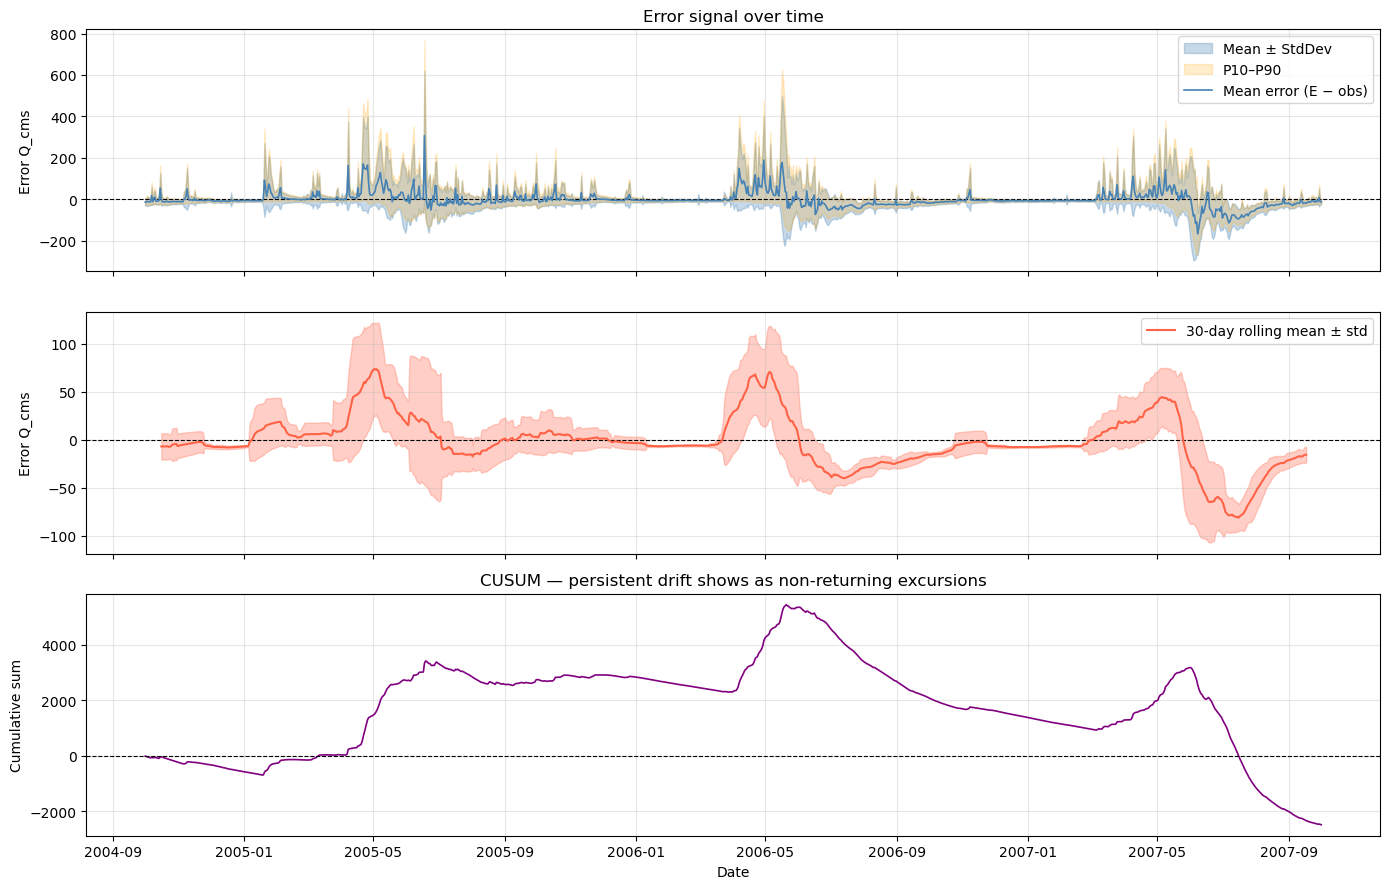

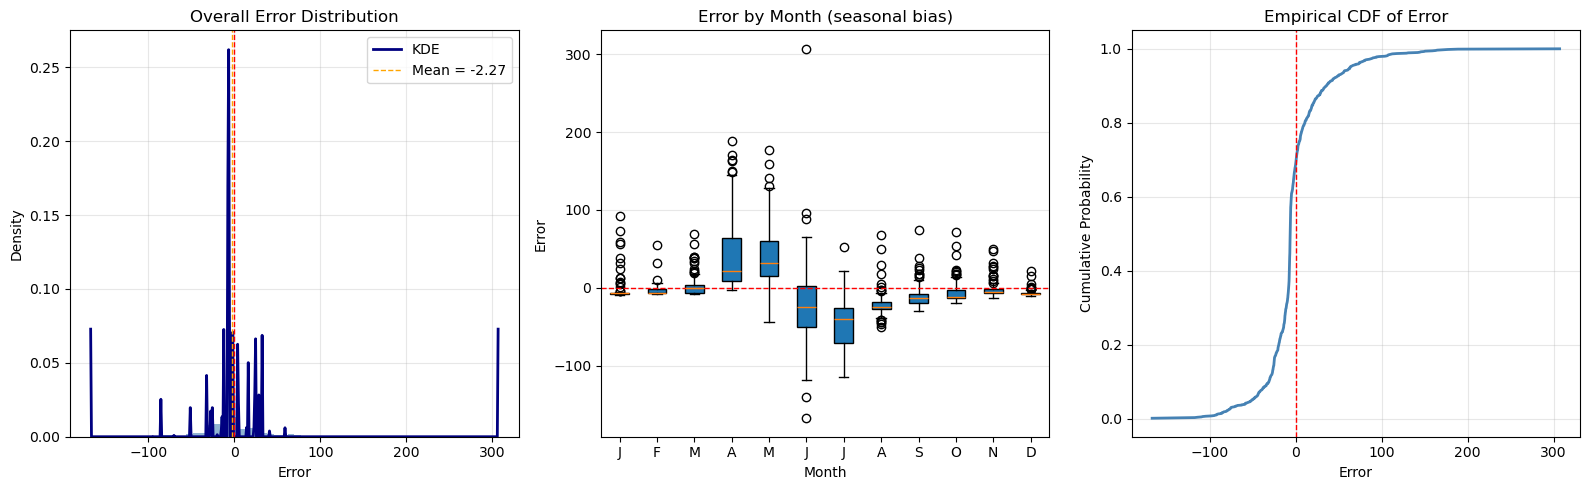

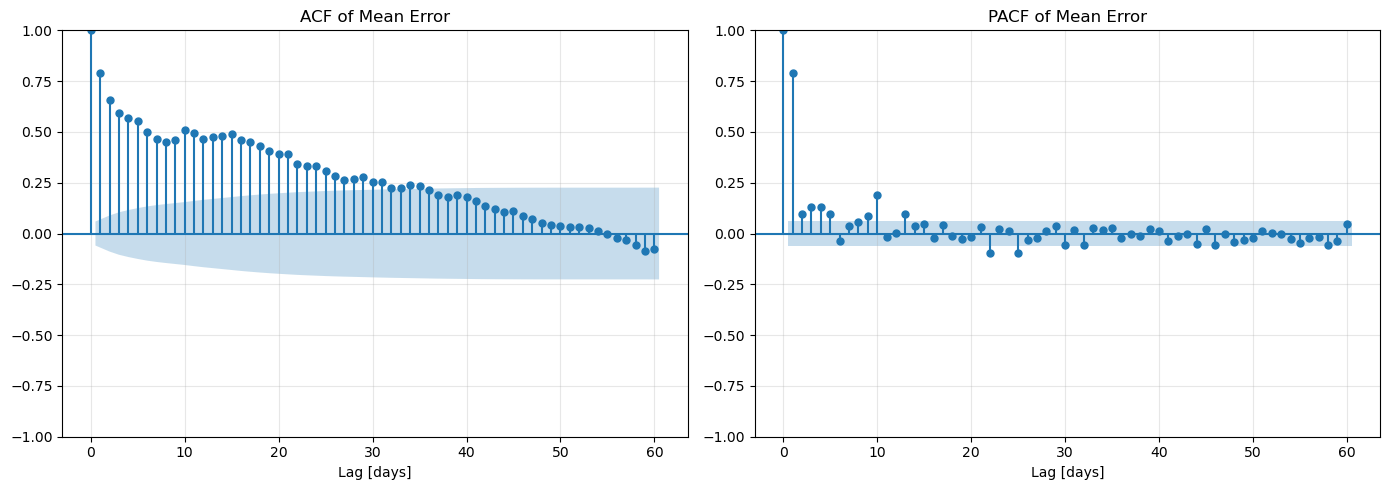


  Lag-1  autocorr : 0.789
  Lag-7  autocorr : 0.466
  Lag-30 autocorr : 0.257
  Lag-60 autocorr : -0.079

=== Stationarity Tests ===
  ADF  stat=-3.4951  p=0.0081  → STATIONARY at 5%
       critical values: {'1%': np.float64(-3.4364533503600962), '5%': np.float64(-2.864234857527328), '10%': np.float64(-2.568204837482531)}
  KPSS stat=0.7563  p=0.0100  → NON-STATIONARY at 5%
       critical values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


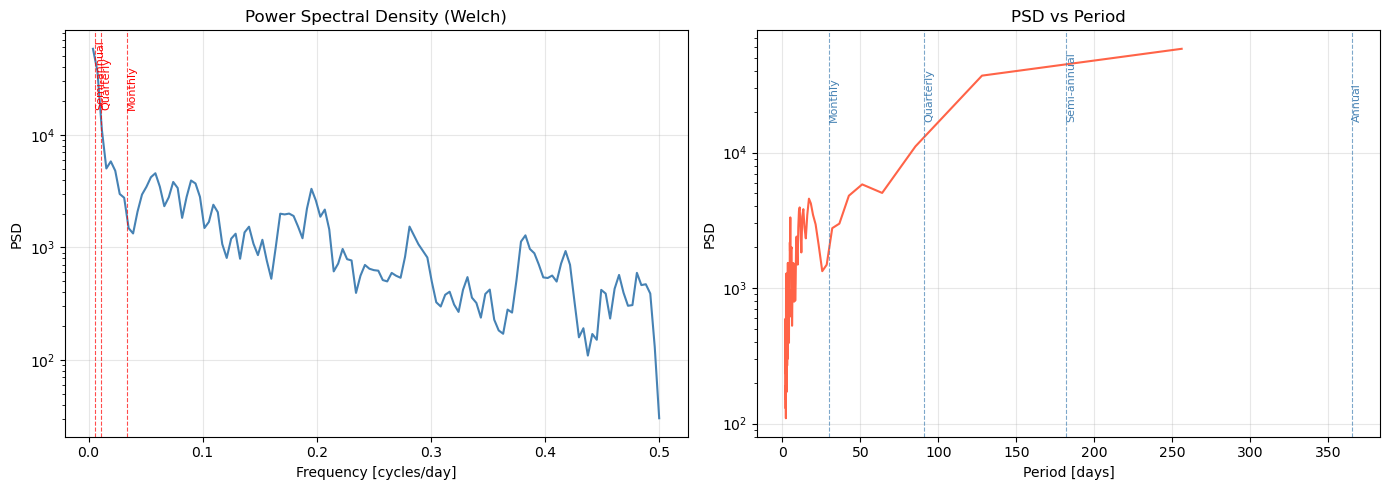

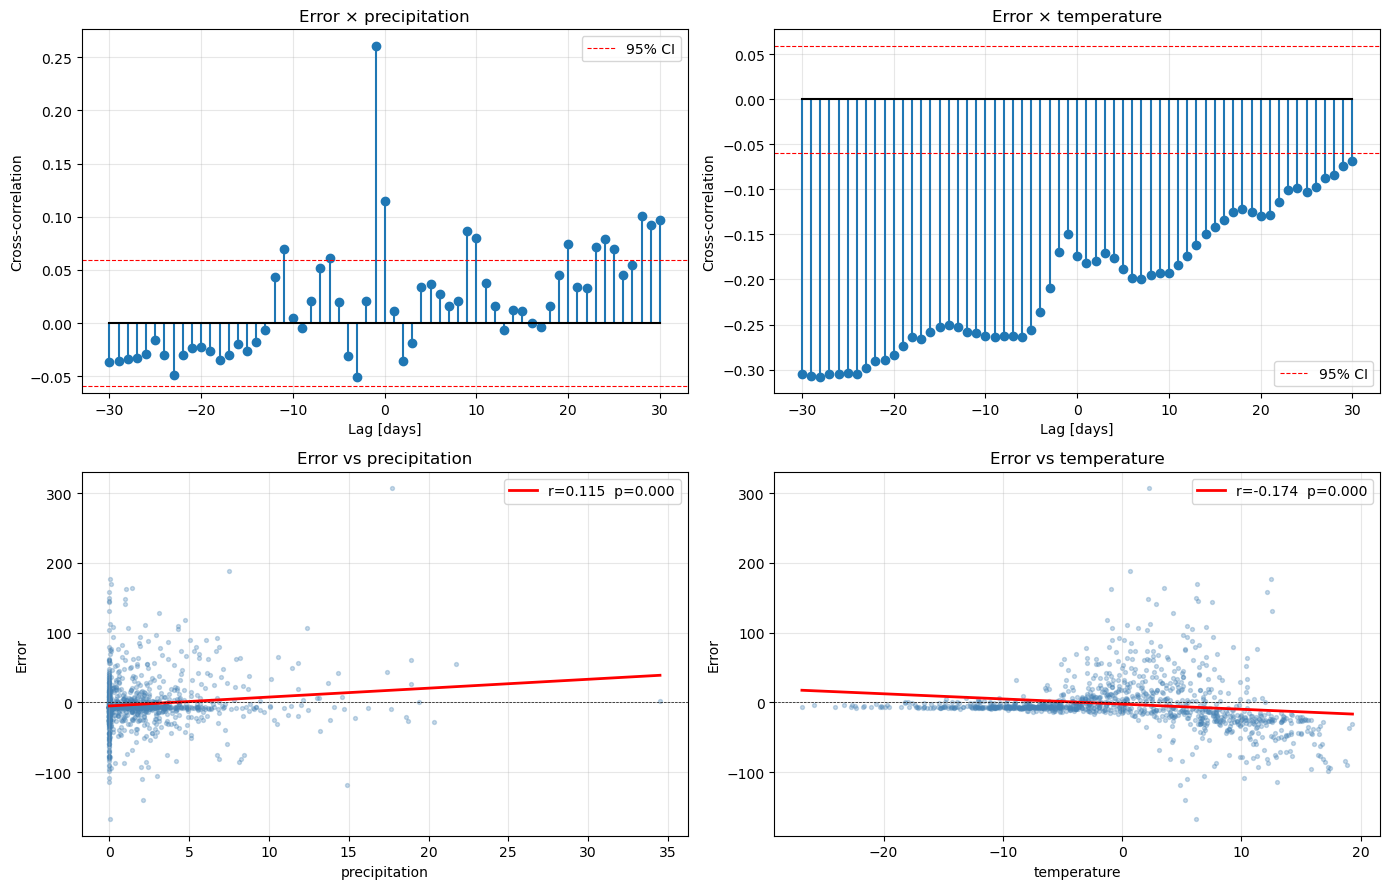

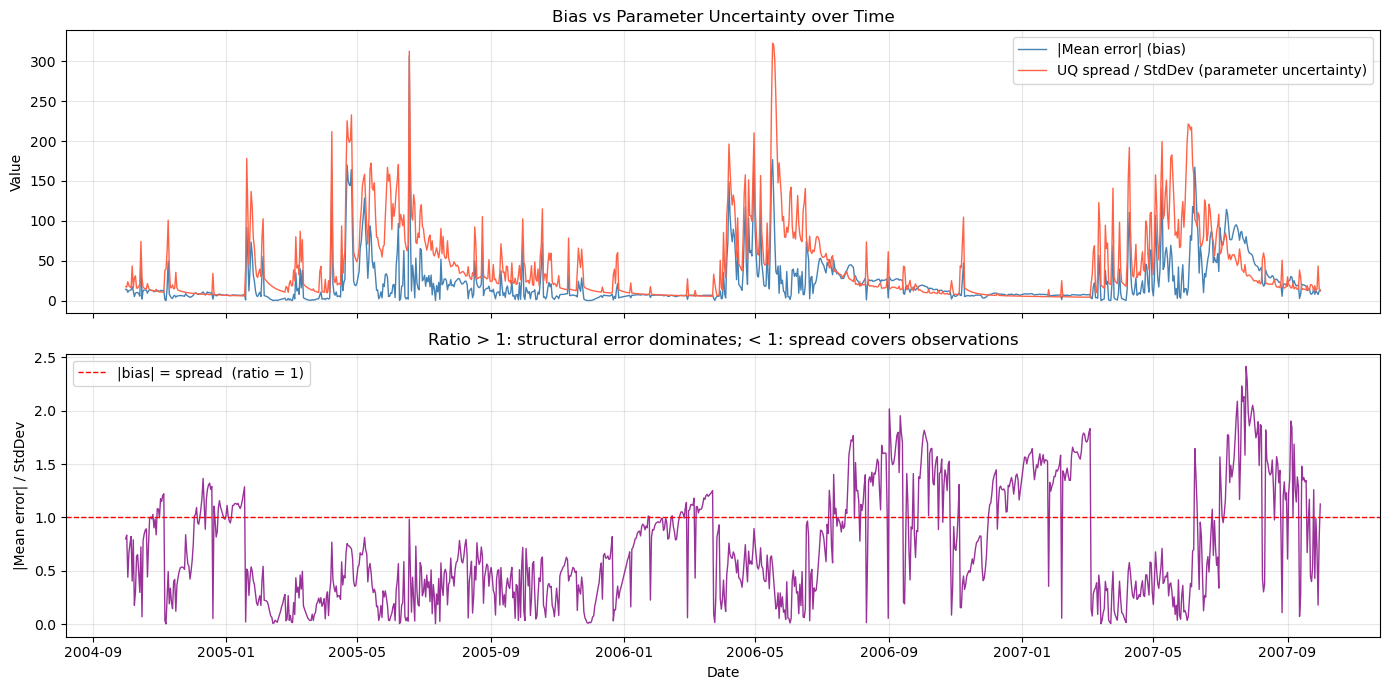


  Timesteps where |bias| > UQ spread: 328 / 1096  (29.9%)

=== AR Order Selection ===
  PACF cutoff → p = 13
  AIC         → p = 20
  BIC         → p = 20  (used by default)
  HQIC        → p = 20
  Significant PACF lags: [1, 2, 3, 4, 5, 9, 10, 13]


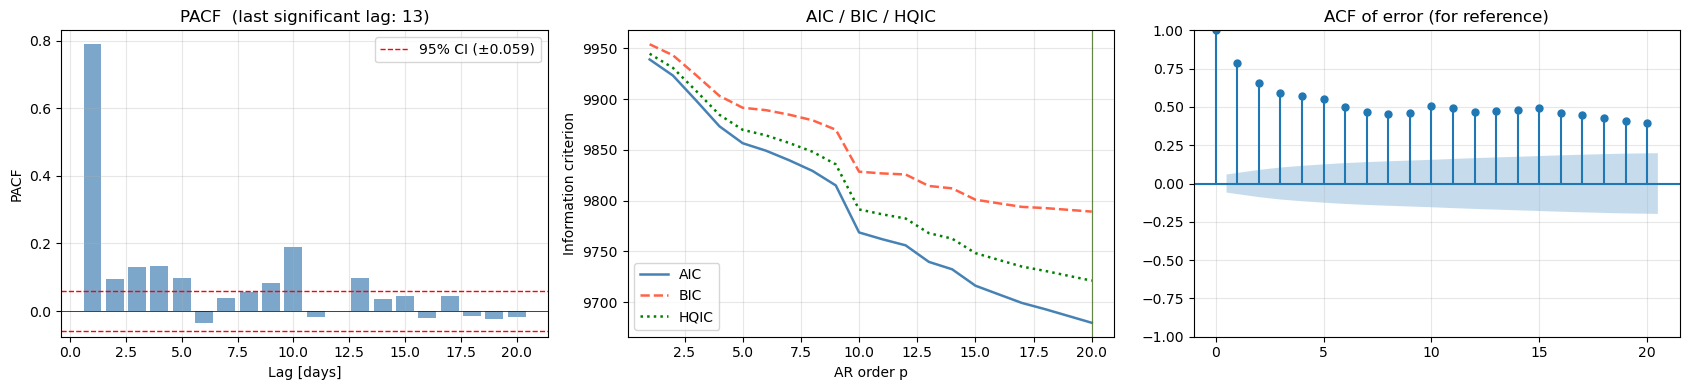


=== AR(20) Fit ===
  Intercept     : -0.1806
  Coefficients φ: [0.6585, -0.0053, 0.0174, 0.0581, 0.0882, -0.0648, -0.0024, -0.0094, -0.042, 0.1928, -0.0167, -0.069, 0.0737, 0.006, 0.0601, -0.0477, 0.0533, 0.0022, -0.0125, -0.0188]
  Innovation std σ_η = 21.297  (σ_ε = 36.746,  variance reduced by 66.4%)


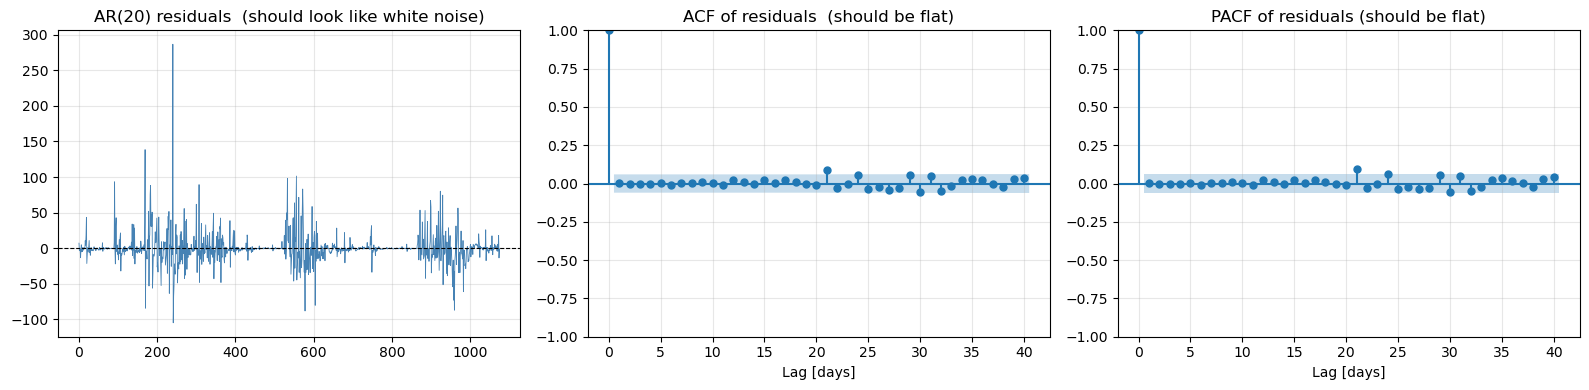

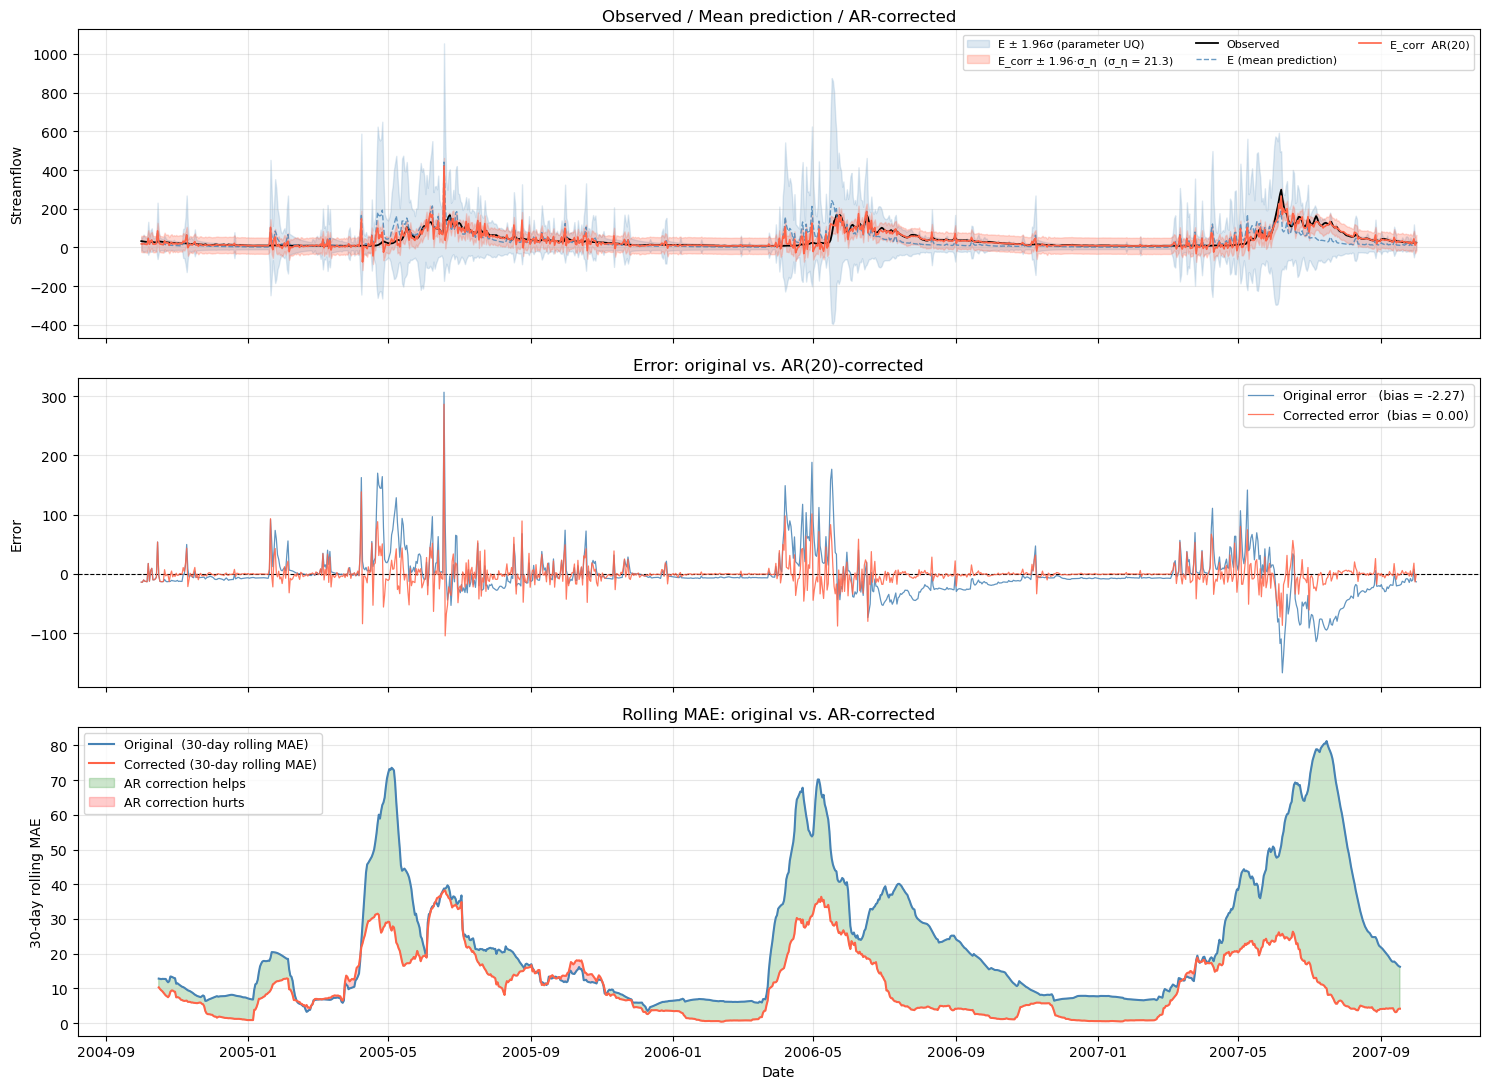


Metric             Original AR(20) corrected    Change
──────────────────────────────────────────────────────
Bias                 -2.267            0.000    +2.267
MAE                  22.757           10.802   -11.955
RMSE                 36.800           21.297   -15.502
Lag-1 ACF             0.789            0.001    -0.788
Lag-7 ACF             0.466            0.001    -0.465

Done. Figures saved to /Users/katarinagrcic/Documents/Ivana_Phd/UQEF-Dynamic/data/HBV-SASK-data/paper_uqef_dynamic_sim/hbv_uq_cm4.0332


In [36]:
from uqef_dynamic.scientific_pipelines.error_signal_analysis import run_error_analysis
df_err, ar_model = run_error_analysis(
    df_statistics_and_measured,
    qoi_column="Q_cms",
    save_dir=directory_for_saving_plots, #None, #pathlib.Path("error_analysis_output"),  # or None for interactive
    ar_order=None, #3, #None,   # auto-select via BIC; or pass e.g. ar_order=3
)


In [33]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from scipy import signal as sig, stats
import warnings
warnings.filterwarnings('ignore')


In [34]:
qoi_column = "Q_cms"

df_err = df_statistics_and_measured[
    df_statistics_and_measured['qoi'] == qoi_column
].copy().sort_values(by=utility.TIME_COLUMN_NAME).reset_index(drop=True)

# Ensemble mean error = bias of the mean prediction
df_err['mean_error'] = df_err['E'] - df_err['measured']

if 'StdDev' in df_err.columns:
    df_err['error_e_minus_std'] = df_err['mean_error'] - df_err['StdDev']
    df_err['error_e_plus_std']  = df_err['mean_error'] + df_err['StdDev']
if 'P10' in df_err.columns:
    df_err['error_p10'] = df_err['P10'] - df_err['measured']
    df_err['error_p90'] = df_err['P90'] - df_err['measured']

error_ts = df_err.set_index(utility.TIME_COLUMN_NAME)['mean_error'].dropna()

print(f"Timesteps: {len(error_ts)}  |  {error_ts.index.min()} → {error_ts.index.max()}")
print(error_ts.describe().to_string())
print(f"\nBias (mean error) : {error_ts.mean():.4f} m³/s")
print(f"MAE               : {error_ts.abs().mean():.4f} m³/s")
print(f"RMSE              : {np.sqrt((error_ts**2).mean()):.4f} m³/s")


Timesteps: 1096  |  2004-10-01 00:00:00 → 2007-10-01 00:00:00
count    1096.000000
mean       -0.511638
std        12.815488
min      -112.792565
25%        -1.876721
50%        -0.214692
75%         2.693429
max       102.033004

Bias (mean error) : -0.5116 m³/s
MAE               : 6.4202 m³/s
RMSE              : 12.8199 m³/s


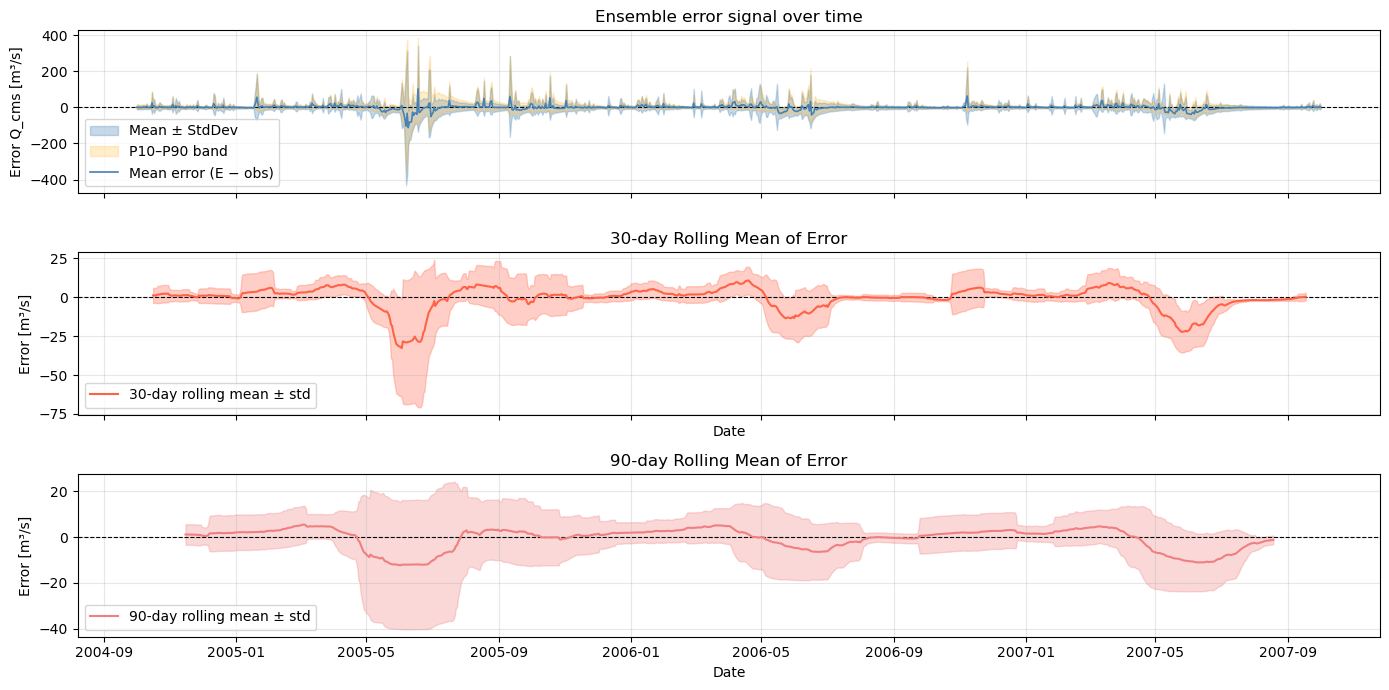

In [97]:
### Error time series + rolling statistics
# When does the model over/underpredict? Any trend?

fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)

ax = axes[0]
ax.axhline(0, color='black', lw=0.8, ls='--')
if 'error_e_minus_std' in df_err.columns:
    ax.fill_between(df_err[utility.TIME_COLUMN_NAME],
                    df_err['error_e_minus_std'], df_err['error_e_plus_std'],
                    alpha=0.3, color='steelblue', label='Mean ± StdDev')
if 'error_p10' in df_err.columns:
    ax.fill_between(df_err[utility.TIME_COLUMN_NAME],
                    df_err['error_p10'], df_err['error_p90'],
                    alpha=0.2, color='orange', label='P10–P90 band')
ax.plot(df_err[utility.TIME_COLUMN_NAME], df_err['mean_error'],
        color='steelblue', lw=1.2, label='Mean error (E − obs)')
ax.set_ylabel('Error Q_cms [m³/s]')
ax.set_title('Ensemble error signal over time')
ax.legend(); ax.grid(alpha=0.3)

window = 30
rolling_mean = error_ts.rolling(window, center=True).mean()
rolling_std  = error_ts.rolling(window, center=True).std()
ax2 = axes[1]
ax2.axhline(0, color='black', lw=0.8, ls='--')
ax2.fill_between(rolling_mean.index,
                 rolling_mean - rolling_std, rolling_mean + rolling_std,
                 alpha=0.3, color='tomato')
ax2.plot(rolling_mean.index, rolling_mean, color='tomato', lw=1.5,
         label=f'{window}-day rolling mean ± std')
ax2.set_ylabel('Error [m³/s]'); ax2.set_xlabel('Date')
ax2.set_title(f'{window}-day Rolling Mean of Error')
ax2.legend(); ax2.grid(alpha=0.3)

# Plot the rolling statistics
window = 90
rolling_mean = error_ts.rolling(window, center=True).mean()
rolling_std  = error_ts.rolling(window, center=True).std()
ax3 = axes[2]
ax3.axhline(0, color='black', lw=0.8, ls='--')
ax3.fill_between(rolling_mean.index,
                 rolling_mean - rolling_std, rolling_mean + rolling_std,
                 alpha=0.3, color='lightcoral')
ax3.plot(rolling_mean.index, rolling_mean, color='lightcoral', lw=1.5,
         label=f'{window}-day rolling mean ± std')
ax3.set_ylabel('Error [m³/s]'); ax3.set_xlabel('Date')
ax3.set_title(f'{window}-day Rolling Mean of Error')
ax3.legend(); ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(directory_for_saving_plots / "error_time_series.pdf", format="pdf")
plt.show()


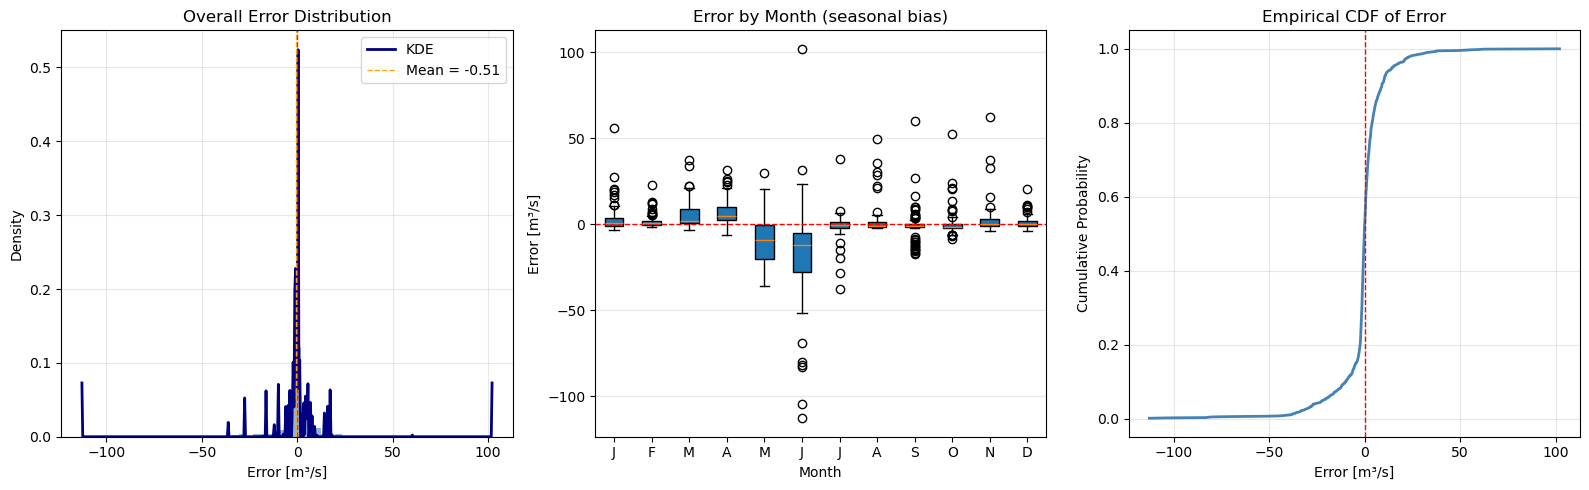

In [98]:
### Error distribution: histogram, monthly boxplot, empirical CDF
# Is the error Gaussian? Is there seasonal bias (e.g., worse in spring snowmelt)?

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogram + KDE
ax = axes[0]
ax.hist(error_ts, bins=60, density=True, alpha=0.6, color='steelblue')
t = np.linspace(error_ts.min(), error_ts.max(), 500)
kde = cp.GaussianKDE(error_ts.values, h_mat=0.005**2)
ax.plot(t, kde.pdf(t), color='navy', lw=2, label='KDE')
ax.axvline(0, color='red', ls='--', lw=1)
ax.axvline(error_ts.mean(), color='orange', ls='--', lw=1,
           label=f'Mean = {error_ts.mean():.2f}')
ax.set_xlabel('Error [m³/s]'); ax.set_ylabel('Density')
ax.set_title('Overall Error Distribution'); ax.legend(); ax.grid(alpha=0.3)

# Monthly boxplot
df_err['month'] = pd.to_datetime(df_err[utility.TIME_COLUMN_NAME]).dt.month
monthly = [df_err[df_err['month']==m]['mean_error'].dropna().values for m in range(1,13)]
ax2 = axes[1]
ax2.boxplot(monthly, labels=list('JFMAMJJASOND'), patch_artist=True)
ax2.axhline(0, color='red', ls='--', lw=1)
ax2.set_xlabel('Month'); ax2.set_ylabel('Error [m³/s]')
ax2.set_title('Error by Month (seasonal bias)'); ax2.grid(alpha=0.3, axis='y')

# Empirical CDF
ax3 = axes[2]
sorted_err = np.sort(error_ts)
cdf = np.arange(1, len(sorted_err)+1) / len(sorted_err)
ax3.plot(sorted_err, cdf, color='steelblue', lw=2)
ax3.axvline(0, color='red', ls='--', lw=1)
ax3.set_xlabel('Error [m³/s]'); ax3.set_ylabel('Cumulative Probability')
ax3.set_title('Empirical CDF of Error'); ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(directory_for_saving_plots / "error_distribution.pdf", format="pdf")
plt.show()


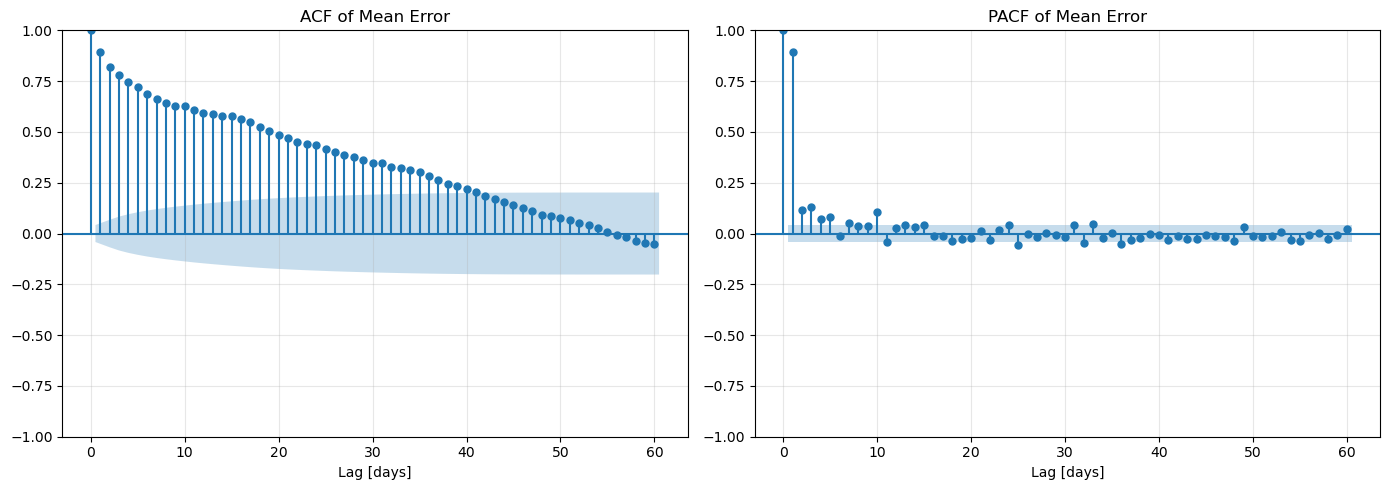

Lag-1  autocorrelation: 0.894
Lag-7  autocorrelation: 0.664
Lag-30 autocorrelation: 0.351
Lag-30 autocorrelation: -0.053
Lag-30 autocorrelation: -0.164


In [38]:
### ACF / PACF: is the error temporally persistent?
# Is today's error predictable from yesterday's? (persistence → AR structure)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(error_ts, lags=60, ax=axes[0], alpha=0.05, title='ACF of Mean Error')
plot_pacf(error_ts, lags=60, ax=axes[1], alpha=0.05, title='PACF of Mean Error', method='ywm')
for ax in axes:
    ax.set_xlabel('Lag [days]'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(directory_for_saving_plots / "error_acf_pacf.pdf", format="pdf")
plt.show()

print(f"Lag-1  autocorrelation: {error_ts.autocorr(1):.3f}")
print(f"Lag-7  autocorrelation: {error_ts.autocorr(7):.3f}")
print(f"Lag-30 autocorrelation: {error_ts.autocorr(30):.3f}")
print(f"Lag-30 autocorrelation: {error_ts.autocorr(60):.3f}")
print(f"Lag-30 autocorrelation: {error_ts.autocorr(90):.3f}")


In [39]:
### Stationarity tests (ADF + KPSS)
# Is the error process stationary, or does its mean/variance drift?

err_clean = error_ts.values

adf_stat, adf_p, _, _, adf_crit, _ = adfuller(err_clean, autolag='AIC')
print("=== Augmented Dickey-Fuller (H0: unit root = non-stationary) ===")
print(f"  ADF statistic : {adf_stat:.4f}")
print(f"  p-value       : {adf_p:.4f}  →  {'STATIONARY' if adf_p < 0.05 else 'NON-STATIONARY'} at 5%")
print(f"  Critical vals : {adf_crit}")

kpss_stat, kpss_p, _, kpss_crit = kpss(err_clean, regression='c', nlags='auto')
print("\n=== KPSS (H0: stationary) ===")
print(f"  KPSS statistic: {kpss_stat:.4f}")
print(f"  p-value       : {kpss_p:.4f}  →  {'NON-STATIONARY' if kpss_p < 0.05 else 'STATIONARY'} at 5%")
print(f"  Critical vals : {kpss_crit}")


=== Augmented Dickey-Fuller (H0: unit root = non-stationary) ===
  ADF statistic : -4.9308
  p-value       : 0.0000  →  STATIONARY at 5%
  Critical vals : {'1%': np.float64(-3.4333712566259007), '5%': np.float64(-2.8628746849930136), '10%': np.float64(-2.567480519733324)}

=== KPSS (H0: stationary) ===
  KPSS statistic: 0.1683
  p-value       : 0.1000  →  STATIONARY at 5%
  Critical vals : {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


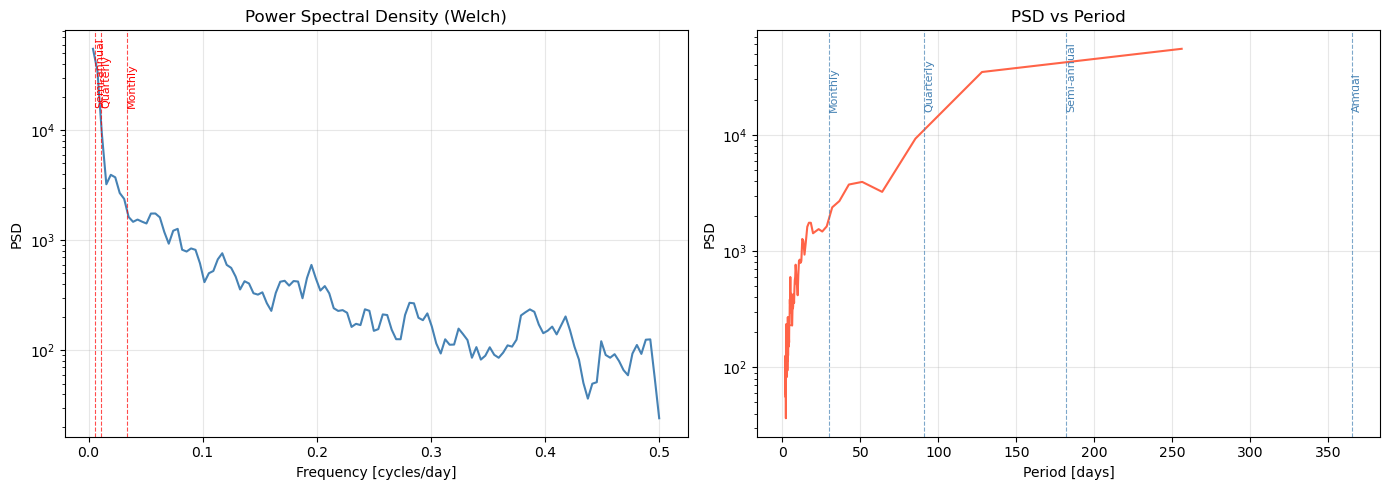

In [40]:
### Power spectral density: dominant periods in the error
# Are there periodic error patterns (annual cycle, monthly)?

freqs, psd = sig.welch(error_ts.values, fs=1.0, nperseg=min(len(error_ts)//4, 256))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.semilogy(freqs[1:], psd[1:], color='steelblue')
for period, label in [(365,'Annual'), (182,'Semi-annual'), (91,'Quarterly'), (30,'Monthly')]:
    if 1/period >= freqs[1]:
        ax.axvline(1/period, color='red', ls='--', lw=0.8, alpha=0.7)
        ax.text(1/period, psd[1:].max()*0.3, label, rotation=90, fontsize=8, color='red')
ax.set_xlabel('Frequency [cycles/day]'); ax.set_ylabel('PSD')
ax.set_title('Power Spectral Density (Welch)'); ax.grid(alpha=0.3)

periods = np.where(freqs > 0, 1/freqs, np.inf)
valid = (periods < 400) & (periods > 2)
ax2 = axes[1]
ax2.semilogy(periods[valid], psd[valid], color='tomato')
for period, label in [(365,'Annual'), (182,'Semi-annual'), (91,'Quarterly'), (30,'Monthly')]:
    ax2.axvline(period, color='steelblue', ls='--', lw=0.8, alpha=0.7)
    ax2.text(period, psd[valid].max()*0.3, label, rotation=90, fontsize=8, color='steelblue')
ax2.set_xlabel('Period [days]'); ax2.set_ylabel('PSD')
ax2.set_title('PSD vs Period'); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(directory_for_saving_plots / "error_psd.pdf", format="pdf")
plt.show()


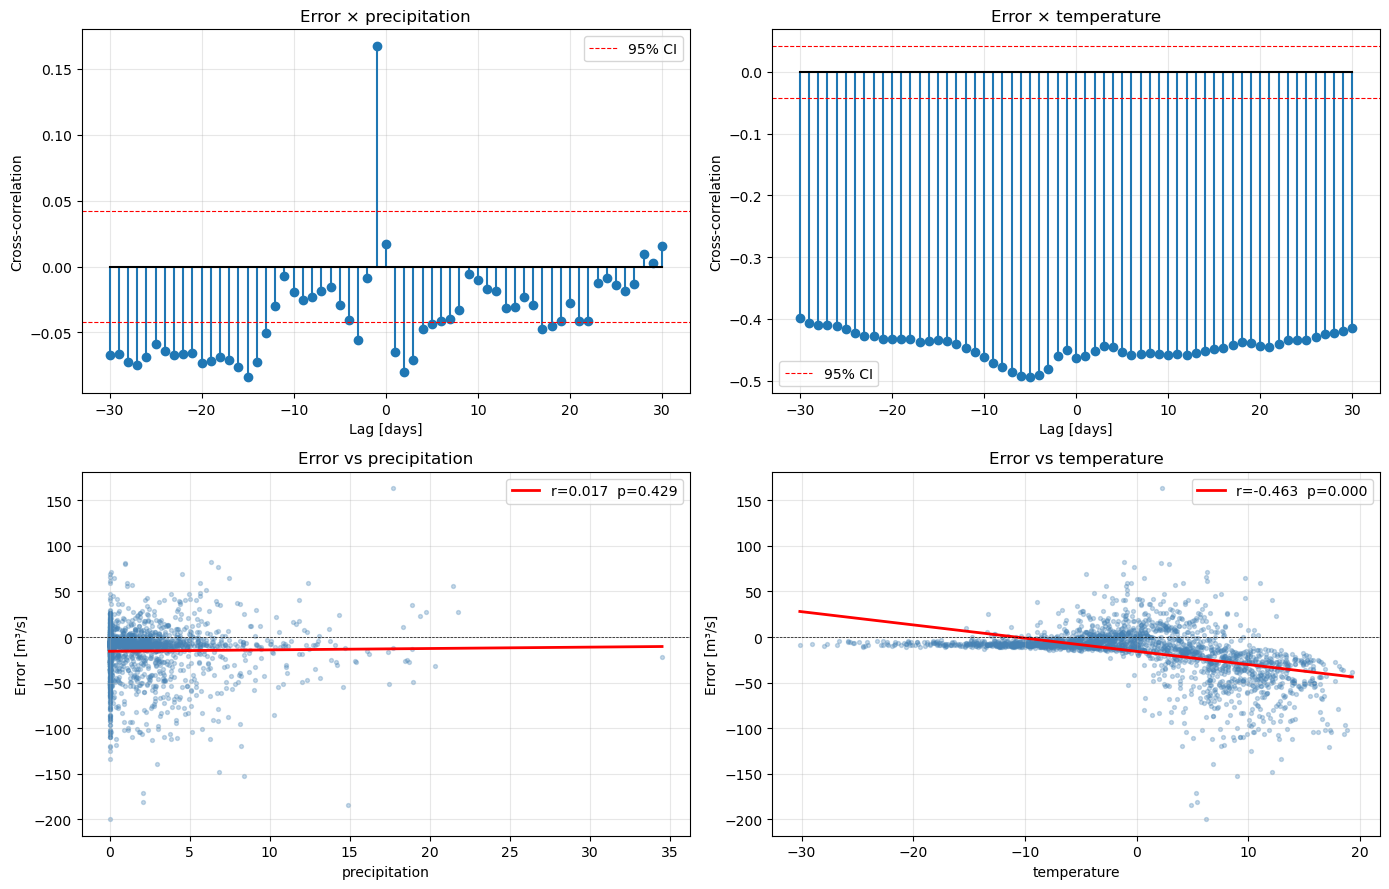

In [41]:
### Cross-correlation of error with forcing (precipitation, temperature)
# Is the error correlated with precipitation or temperature, and at what lag?

forcing_cols = [c for c in ['precipitation', 'temperature'] if c in df_err.columns]

fig, axes = plt.subplots(2, len(forcing_cols), figsize=(7*len(forcing_cols), 9))
if len(forcing_cols) == 1:
    axes = axes.reshape(2, 1)

for ci, forcing in enumerate(forcing_cols):
    aligned = pd.concat(
        [df_err.set_index(utility.TIME_COLUMN_NAME)['mean_error'],
         df_err.set_index(utility.TIME_COLUMN_NAME)[forcing]], axis=1
    ).dropna()
    e, f = aligned['mean_error'], aligned[forcing]

    max_lags = 30
    lags = range(-max_lags, max_lags+1)
    xcorr = [e.corr(f.shift(-lag)) for lag in lags]
    ci95 = 1.96 / np.sqrt(len(e))

    ax = axes[0, ci]
    ax.stem(list(lags), xcorr, markerfmt='C0o', linefmt='C0-', basefmt='k-')
    ax.axhline(ci95, color='red', ls='--', lw=0.8, label='95% CI')
    ax.axhline(-ci95, color='red', ls='--', lw=0.8)
    ax.set_xlabel('Lag [days]'); ax.set_ylabel('Cross-correlation')
    ax.set_title(f'Error × {forcing}'); ax.legend(); ax.grid(alpha=0.3)

    ax2 = axes[1, ci]
    ax2.scatter(f, e, alpha=0.3, s=8, color='steelblue')
    m, b, r, p, _ = stats.linregress(f, e)
    x_line = np.linspace(f.min(), f.max(), 100)
    ax2.plot(x_line, m*x_line + b, color='red', lw=2,
             label=f'r={r:.3f}  p={p:.3f}')
    ax2.axhline(0, color='black', lw=0.5, ls='--')
    ax2.set_xlabel(forcing); ax2.set_ylabel('Error [m³/s]')
    ax2.set_title(f'Error vs {forcing}'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(directory_for_saving_plots / "error_vs_forcing.pdf", format="pdf")
plt.show()


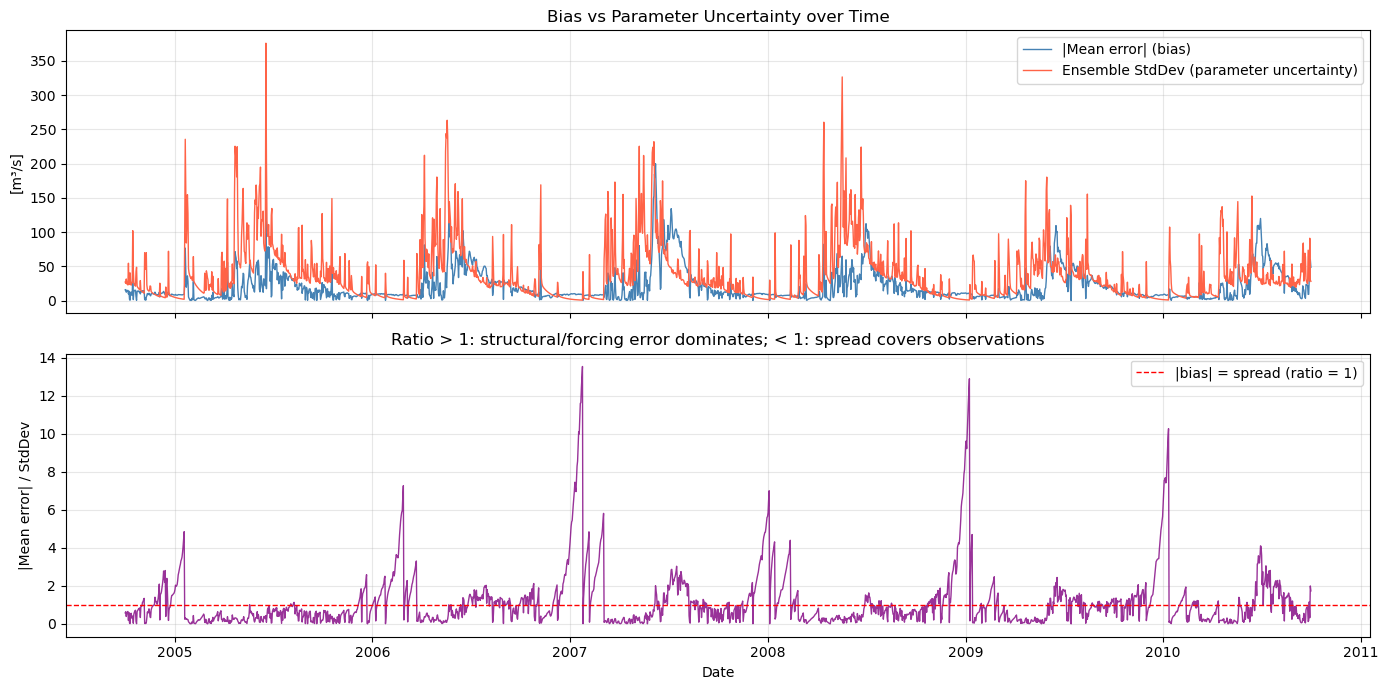

Timesteps where |bias| > ensemble spread: 833 / 2192  (38.0%)


In [42]:
### Bias vs ensemble spread: when does uncertainty from parameters dominate?
# Is the model uncertainty from parameters enough to cover the bias, or does structural error dominate?

if 'StdDev' in df_err.columns:
    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

    ax = axes[0]
    ax.plot(df_err[utility.TIME_COLUMN_NAME], df_err['mean_error'].abs(),
            color='steelblue', lw=1, label='|Mean error| (bias)')
    ax.plot(df_err[utility.TIME_COLUMN_NAME], df_err['StdDev'],
            color='tomato', lw=1, label='Ensemble StdDev (parameter uncertainty)')
    ax.set_ylabel('[m³/s]')
    ax.set_title('Bias vs Parameter Uncertainty over Time')
    ax.legend(); ax.grid(alpha=0.3)

    ratio = df_err['mean_error'].abs() / df_err['StdDev'].replace(0, np.nan)
    ax2 = axes[1]
    ax2.plot(df_err[utility.TIME_COLUMN_NAME], ratio, color='purple', lw=1, alpha=0.8)
    ax2.axhline(1.0, color='red', ls='--', lw=1,
                label='|bias| = spread (ratio = 1)')
    ax2.set_ylabel('|Mean error| / StdDev'); ax2.set_xlabel('Date')
    ax2.set_title('Ratio > 1: structural/forcing error dominates; < 1: spread covers observations')
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(directory_for_saving_plots / "error_vs_spread.pdf", format="pdf")
    plt.show()

    print(f"Timesteps where |bias| > ensemble spread: {(ratio > 1).sum()} / {len(ratio)}  ({(ratio>1).mean():.1%})")


## AR Error Correction as a Post-Processing DA Step

ε(t) = φ · ε(t−1) + η(t),   η(t) ~ N(0, σ²_η) \
AR correction - Corrected mean prediction: E_corr(t) = E(t) − φ · ε(t−1)

The innovation variance (the unexplained part after the AR correction) is: \
σ²_η = σ²_ε · (1 − φ²) = σ²_ε · (1 − 0.799) ≈ 0.20 · σ²_ε

Partial Autocorrelation Function — it measures the correlation between ε(t) and ε(t−k) after removing the linear influence of all intermediate lags 1, 2, …, k−1.

AR(P) - fit OLS
ε(t) = α₁·ε(t−1) + α₂·ε(t−2) + … + αₖ·ε(t−k) + residual



In [50]:
### Autocorrelation and partial autocorrelation of the error signal

import statsmodels.api as sm
acf = sm.tsa.acf(error_ts.values, nlags=30)
pacf = sm.tsa.pacf(error_ts.values, nlags=30)
print(f"ACF: {acf}")
print(f"PACF: {pacf}")

ACF: [1.         0.89328003 0.82167376 0.77822366 0.74423494 0.72038708
 0.68728307 0.66352434 0.64472549 0.62879707 0.62916968 0.6092144
 0.59341154 0.58587182 0.57880686 0.57670533 0.56359612 0.54732047
 0.52653919 0.50449695 0.48615484 0.47109486 0.45091396 0.43862744
 0.43472165 0.41796301 0.40282069 0.38725329 0.37531424 0.36403807
 0.34935188]
PACF: [ 1.          0.89368773  0.11795208  0.12885848  0.07436236  0.08143297
 -0.01115896  0.05064353  0.03694547  0.03764789  0.10567019 -0.04392997
  0.02572078  0.04388915  0.03035568  0.04254465 -0.01271632 -0.01400366
 -0.03823249 -0.02501199 -0.02135262  0.01251681 -0.0313803   0.01995456
  0.04293833 -0.05714199 -0.00443909 -0.01716111  0.00326105 -0.00641394
 -0.01592491]


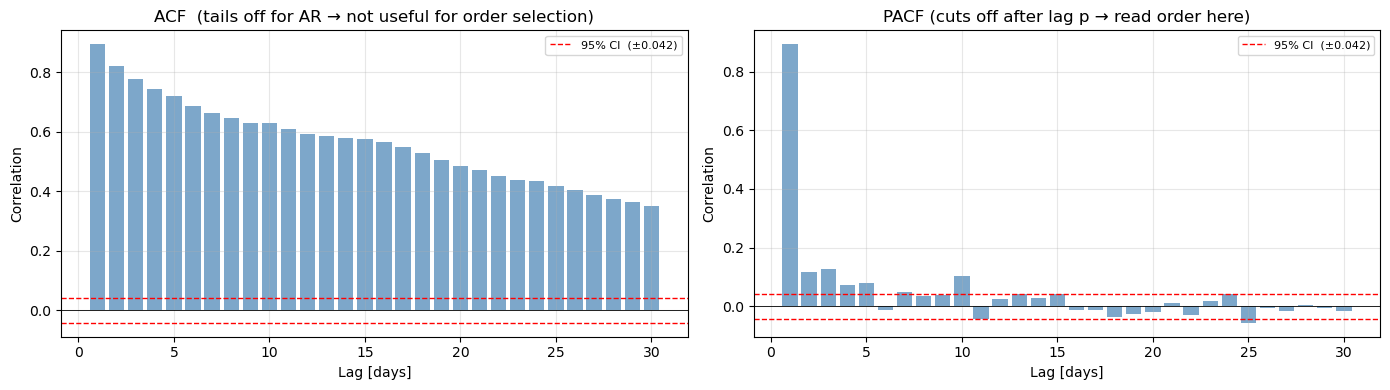

Last significant PACF lag: 25  →  suggested AR order: p = 25
Significant lags: [1, 2, 3, 4, 5, 7, 10, 11, 13, 24, 25]


In [51]:
### Trying to identify if AR(p) structure is present in the error signal, and if so, what order p to use for an AR model.
from statsmodels.tsa.stattools import pacf, acf
import matplotlib.pyplot as plt
import numpy as np

max_lags = 30
ci = 1.96 / np.sqrt(len(error_ts))          # 95% significance threshold

pacf_vals = pacf(error_ts.values, nlags=max_lags, method="ywm")
acf_vals  = acf(error_ts.values,  nlags=max_lags)

# --- Visualise ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

lags = np.arange(max_lags + 1)
for ax, vals, title in [
    (axes[0], acf_vals,  "ACF  (tails off for AR → not useful for order selection)"),
    (axes[1], pacf_vals, "PACF (cuts off after lag p → read order here)"),
]:
    ax.bar(lags[1:], vals[1:], color="steelblue", alpha=0.7)
    ax.axhline( ci, color="red", ls="--", lw=1, label=f"95% CI  (±{ci:.3f})")
    ax.axhline(-ci, color="red", ls="--", lw=1)
    ax.axhline( 0,  color="black", lw=0.6)
    ax.set_xlabel("Lag [days]"); ax.set_ylabel("Correlation")
    ax.set_title(title); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- Programmatic cutoff ---
significant = np.where(np.abs(pacf_vals[1:]) > ci)[0] + 1   # lag indices
p_pacf = int(significant[-1]) if len(significant) > 0 else 1
print(f"Last significant PACF lag: {p_pacf}  →  suggested AR order: p = {p_pacf}")
print(f"Significant lags: {significant.tolist()}")


In [ ]:
### Trying to identify if ARMA or ARIMA model can be fitted to the error signal


In [ ]:
import numpy as np
from statsmodels.regression.linear_model import OLS
import statsmodels.api as sm

# error_ts is the time series of mean errors (ensemble mean - observed), i.e., df_err["mean_error"]

# --- Step 1: Fit AR(1) on historical error (e.g., calibration period) ---
eps = error_ts.values          # ε(t) array
y  = eps[1:]                   # ε(t)
X  = sm.add_constant(eps[:-1]) # ε(t-1)
fit = OLS(y, X).fit()
phi_0  = fit.params[0]         # intercept (should be ~bias · (1-φ))
phi    = fit.params[1]         # AR(1) coefficient
sigma_eta = np.std(fit.resid)  # innovation std

print(f"φ = {phi:.3f},  φ_0 = {phi_0:.3f}, σ_η = {sigma_eta:.3f} m³/s")

# --- Step 2: Apply causal correction to the full period ---
df_err["E_corr"] = np.nan
for t in range(1, len(df_err)):
    eps_prev = df_err["mean_error"].iloc[t - 1]
    if not np.isnan(eps_prev):
        df_err.loc[df_err.index[t], "E_corr"] = (
            df_err["E"].iloc[t] - (phi_0 + phi * eps_prev)
        )

# Corrected error
df_err["error_corr"] = df_err["E_corr"] - df_err["measured"]

# Corrected uncertainty bands (constant innovation std)
df_err["E_corr_lo"] = df_err["E_corr"] - 2 * sigma_eta
df_err["E_corr_hi"] = df_err["E_corr"] + 2 * sigma_eta


φ = 0.894,  φ_0 = -1.635, σ_η = 12.464 m³/s


In [47]:
phi       = error_ts.autocorr(1)
sigma_eps = error_ts.std()
sigma_eta = sigma_eps * np.sqrt(1 - phi**2)   # innovation std after AR(1)
print(f"φ = {phi:.3f},  σ_ε = {sigma_eps:.3f}, σ_η = {sigma_eta:.3f} m³/s")


φ = 0.894,  σ_ε = 27.765, σ_η = 12.464 m³/s


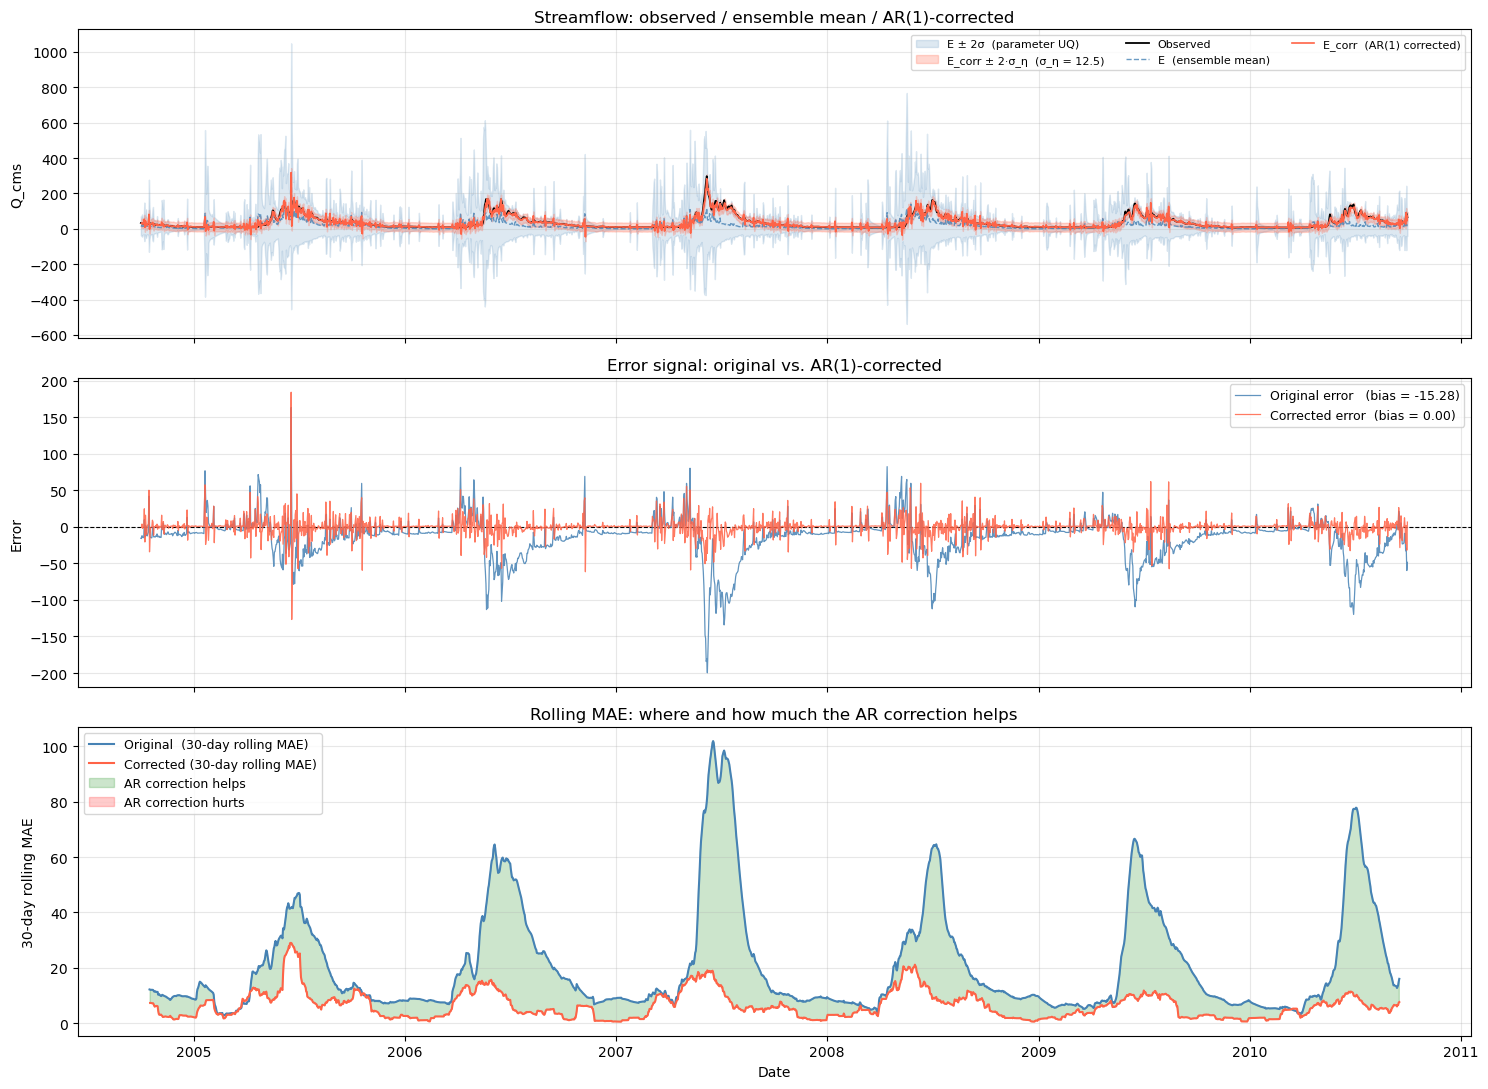


Metric             Original  AR(1) corrected    Change
──────────────────────────────────────────────────────
Bias                -15.281            0.000   +15.281
MAE                  20.857            6.471   -14.386
RMSE                 31.687           12.464   -19.222
Lag-1 ACF             0.894           -0.106    -1.000
Lag-7 ACF             0.664            0.015    -0.649


In [49]:

time = df_err[utility.TIME_COLUMN_NAME]
err_corr_ts = df_err["error_corr"].dropna()

# ── Figure 1: three-panel time-domain comparison ─────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True)

# Panel 1 — streamflow time series with uncertainty bands
ax = axes[0]
if "StdDev" in df_err.columns:
    ax.fill_between(time,
                    df_err["E"] - 2*df_err["StdDev"],
                    df_err["E"] + 2*df_err["StdDev"],
                    alpha=0.18, color="steelblue", label="E ± 2σ  (parameter UQ)")
ax.fill_between(time,
                df_err["E_corr"] - 2*sigma_eta,
                df_err["E_corr"] + 2*sigma_eta,
                alpha=0.25, color="tomato",
                label=f"E_corr ± 2·σ_η  (σ_η = {sigma_eta:.1f})")
ax.plot(time, df_err["measured"],  color="black",     lw=1.3, label="Observed")
ax.plot(time, df_err["E"],         color="steelblue", lw=1.0, ls="--", alpha=0.8, label="E  (ensemble mean)")
ax.plot(time, df_err["E_corr"],    color="tomato",    lw=1.2, label="E_corr  (AR(1) corrected)")
ax.set_ylabel(f"Q_cms")
ax.set_title("Streamflow: observed / ensemble mean / AR(1)-corrected")
ax.legend(ncol=3, fontsize=8); ax.grid(alpha=0.3)

# Panel 2 — error signals
ax2 = axes[1]
ax2.axhline(0, color="black", lw=0.8, ls="--")
ax2.plot(time, df_err["mean_error"],  color="steelblue", lw=0.9, alpha=0.85,
         label=f"Original error   (bias = {df_err['mean_error'].mean():.2f})")
ax2.plot(time, df_err["error_corr"],  color="tomato",    lw=0.9, alpha=0.85,
         label=f"Corrected error  (bias = {df_err['error_corr'].mean():.2f})")
ax2.set_ylabel("Error")
ax2.set_title("Error signal: original vs. AR(1)-corrected")
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

# Panel 3 — 30-day rolling MAE with improvement shading
window = 30
roll_mae_orig = df_err["mean_error"].abs().rolling(window, center=True).mean()
roll_mae_corr = df_err["error_corr"].abs().rolling(window, center=True).mean()

ax3 = axes[2]
ax3.plot(time, roll_mae_orig, color="steelblue", lw=1.5, label="Original  (30-day rolling MAE)")
ax3.plot(time, roll_mae_corr, color="tomato",    lw=1.5, label="Corrected (30-day rolling MAE)")
ax3.fill_between(time, roll_mae_orig, roll_mae_corr,
                 where=(roll_mae_orig >= roll_mae_corr),
                 alpha=0.2, color="green", label="AR correction helps")
ax3.fill_between(time, roll_mae_orig, roll_mae_corr,
                 where=(roll_mae_orig  < roll_mae_corr),
                 alpha=0.2, color="red",   label="AR correction hurts")
ax3.set_ylabel("30-day rolling MAE")
ax3.set_xlabel("Date")
ax3.set_title("Rolling MAE: where and how much the AR correction helps")
ax3.legend(fontsize=9); ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── Figure 2: scatter plots (observed vs predicted) ───────────────────────────
# fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))

# lim = (0, max(df_err["measured"].max(), df_err["E"].max(), df_err["E_corr"].max()) * 1.02)
# for ax, pred, label, color in [
#     (axes2[0], df_err["E"],      "Ensemble mean E",       "steelblue"),
#     (axes2[1], df_err["E_corr"], "AR(1)-corrected E_corr", "tomato"),
# ]:
#     obs = df_err["measured"]
#     m, b, r, _, _ = stats.linregress(obs.dropna(), pred.dropna())
#     ax.scatter(obs, pred, alpha=0.15, s=6, color=color)
#     ax.plot(lim, lim, "k--", lw=0.8, label="1:1")
#     x_line = np.array(lim)
#     ax.plot(x_line, m*x_line + b, color="red", lw=1.5,
#             label=f"fit  r={r:.3f}")
#     ax.set_xlim(lim); ax.set_ylim(lim)
#     ax.set_xlabel("Observed"); ax.set_ylabel("Predicted")
#     ax.set_title(label); ax.legend(fontsize=9); ax.grid(alpha=0.3)

# plt.tight_layout()
# plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'Metric':<14} {'Original':>12} {'AR(1) corrected':>16}  {'Change':>8}")
print("─" * 54)
for label, fn_orig, fn_corr in [
    ("Bias",       error_ts.mean(),                    err_corr_ts.mean()),
    ("MAE",        error_ts.abs().mean(),               err_corr_ts.abs().mean()),
    ("RMSE",       np.sqrt((error_ts**2).mean()),       np.sqrt((err_corr_ts**2).mean())),
    ("Lag-1 ACF",  error_ts.autocorr(1),               err_corr_ts.autocorr(1)),
    ("Lag-7 ACF",  error_ts.autocorr(7),               err_corr_ts.autocorr(7)),
]:
    delta = fn_corr - fn_orig
    print(f"{label:<14} {fn_orig:>12.3f} {fn_corr:>16.3f}  {delta:>+8.3f}")


### Trying to see if other AR(P) might fit better

AIC → p = 40,   BIC → p = 38,   HQIC → p = 40


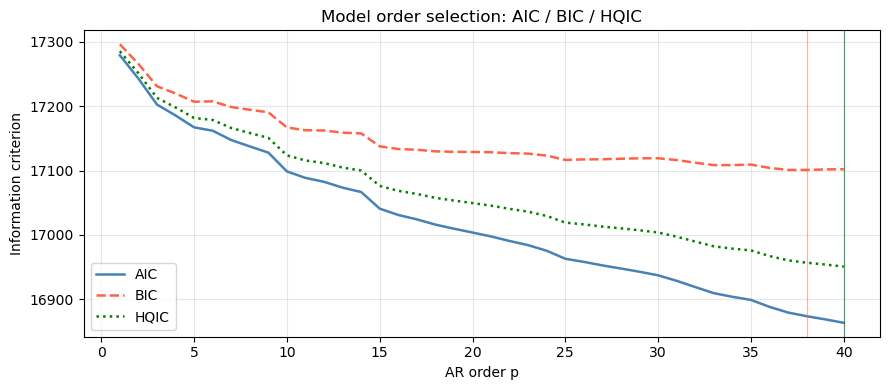

In [55]:
from statsmodels.tsa.ar_model import AutoReg
import pandas as pd

p_max = 40 # 20, 30...
records = []
for p in range(1, p_max + 1):
    res = AutoReg(error_ts.values, lags=p, old_names=False).fit()
    records.append({"p": p, "AIC": res.aic, "BIC": res.bic, "HQIC": res.hqic})

df_ic = pd.DataFrame(records).set_index("p")

p_aic  = int(df_ic["AIC"].idxmin())
p_bic  = int(df_ic["BIC"].idxmin())
p_hqic = int(df_ic["HQIC"].idxmin())
print(f"AIC → p = {p_aic},   BIC → p = {p_bic},   HQIC → p = {p_hqic}")

# Plot IC curves
fig, ax = plt.subplots(figsize=(9, 4))
for col, color, ls in [("AIC","steelblue","-"), ("BIC","tomato","--"), ("HQIC","green",":")]:
    ax.plot(df_ic.index, df_ic[col], color=color, ls=ls, lw=1.8, label=col)
    ax.axvline(df_ic[col].idxmin(), color=color, lw=0.8, alpha=0.5)
ax.set_xlabel("AR order p"); ax.set_ylabel("Information criterion")
ax.set_title("Model order selection: AIC / BIC / HQIC")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [61]:
# Pick order — BIC is conservative and avoids overfitting
p_selected = 1 #p_bic    # or p_pacf; cross-check both

model_ar = AutoReg(error_ts.values, lags=p_selected, old_names=False).fit()
print(model_ar.summary())

phi_vec = model_ar.params[1:]          # AR coefficients φ_1 … φ_p
intercept = model_ar.params[0]
sigma_eta_p = np.std(model_ar.resid)

print(f"\nAR({p_selected}) coefficients: {np.round(phi_vec, 3)}")
print(f"Innovation std σ_η = {sigma_eta_p:.3f}  (vs original σ_ε = {error_ts.std():.3f})")
print(f"Variance explained by AR({p_selected}): {1 - (sigma_eta_p/error_ts.std())**2:.1%}")

# Causal correction
eps = df_err["mean_error"].values.copy()
E_corr_p = df_err["E"].values.copy()

for t in range(p_selected, len(df_err)):
    # AR(p) prediction of ε(t) from ε(t-1)...ε(t-p)
    eps_past = eps[t - p_selected: t][::-1]     # [ε(t-1), ε(t-2), …, ε(t-p)]
    eps_hat  = intercept + phi_vec @ eps_past
    E_corr_p[t] = df_err["E"].iloc[t] - eps_hat

df_err[f"E_corr_ar{p_selected}"] = E_corr_p
df_err[f"error_corr_ar{p_selected}"] = E_corr_p - df_err["measured"]


                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:                 2192
Model:                     AutoReg(1)   Log Likelihood               -8636.463
Method:               Conditional MLE   S.D. of innovations             12.464
Date:                Thu, 09 Jul 2026   AIC                          17278.927
Time:                        00:42:55   BIC                          17296.003
Sample:                             1   HQIC                         17285.168
                                 2192                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.6352      0.304     -5.381      0.000      -2.231      -1.040
y.L1           0.8939      0.010     93.173      0.000       0.875       0.913
                                    Roots           

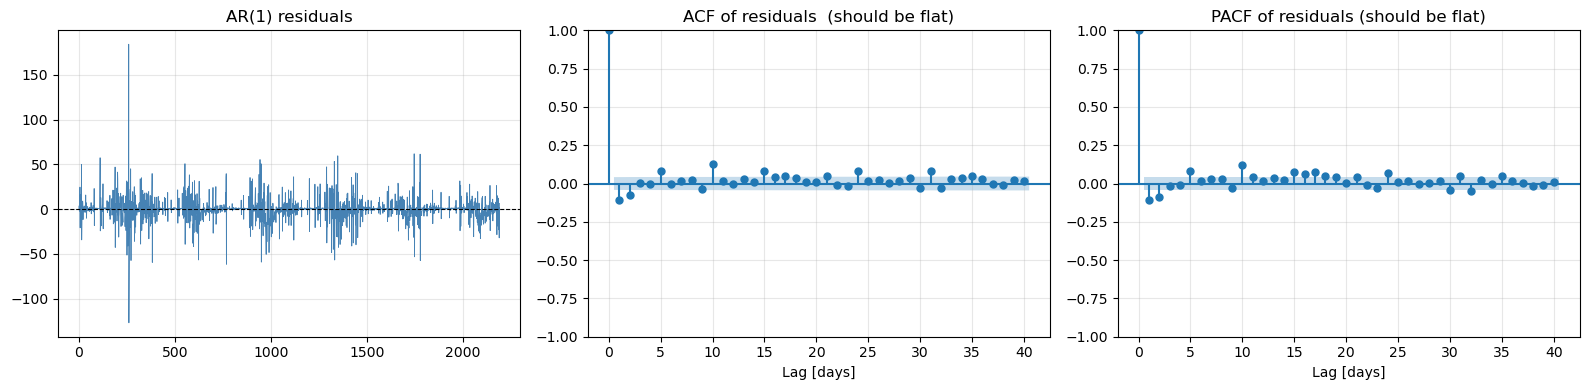

Residual lag-1 autocorr : -0.106  (target: < 0.042)
Residual lag-7 autocorr : 0.015


In [62]:
# Residual diagnostics — did the AR(p) whiten the error? 
# The residuals of a correctly-specified AR(p) should be white noise
resid = pd.Series(model_ar.resid)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(resid.values, lw=0.6, color="steelblue")
axes[0].axhline(0, color="black", lw=0.8, ls="--")
axes[0].set_title(f"AR({p_selected}) residuals"); axes[0].grid(alpha=0.3)

plot_acf( resid, lags=40, ax=axes[1], alpha=0.05, title="ACF of residuals  (should be flat)")
plot_pacf(resid, lags=40, ax=axes[2], alpha=0.05, title="PACF of residuals (should be flat)",
          method="ywm")
for ax in axes[1:]:
    ax.set_xlabel("Lag [days]"); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Residual lag-1 autocorr : {resid.autocorr(1):.3f}  (target: < {ci:.3f})")
print(f"Residual lag-7 autocorr : {resid.autocorr(7):.3f}")


# Describing Statistics Data

### Note: there are two relevant DFs which do not have to be identical necessarily
### df_statistics_and_measured and statisticsObject.df_statistics

In [ ]:
# Note: this works on df_statistics_and_measured
# This does not make much sense when there is more QoIs
for sinlge_qoi in list(df_statistics_and_measured['qoi'].unique()):
    print(f"Description - {sinlge_qoi}")
    df_statistics_and_measured_subset = df_statistics_and_measured[df_statistics_and_measured['qoi']==sinlge_qoi]
    print(df_statistics_and_measured_subset.describe(include=np.number))

In [ ]:
# the same as above - just convenient in multi QoIs set-up
# Note: this works on statisticsObject.df_statistics
statisticsObject.describe_df_statistics()

In [ ]:
# Examing df_statistics_and_measured
df_statistics_and_measured[df_statistics_and_measured["precipitation"]>0]
df_statistics_and_measured[df_statistics_and_measured["E"]<0]

# Plotting different time-series

The functions I am using below:
* uqef_dynamic_utils.plotting_function_single_qoi
* uqef_dynamic_utils.plotting_function_single_qoi_hbv (tailored for HBV)
* uqef_dynamic_utils.plot_forcing_mean_predicted_and_observed_all_qoi (tailored for HBV)
* statisticsObject.plotResults_single_qoi

In [ ]:
dict_what_to_plot = {
    "E_minus_std": False, "E_plus_std": False, 
    "E_minus_2std": True, "E_plus_2std": True,
    "P10": False, "P90": False,
    "StdDev": True, "Skew": False, "Kurt": False, 
    "Sobol_m": False, "Sobol_m2": False, "Sobol_t": False
}

In [ ]:
df_statistics_and_measured.columns

In [ ]:
# Note: from this point on df_statistics_and_measured differs from statisticsObject.df_statistics
set_mean_prediction_to_zero = True
set_lower_predictions_to_zero = True

if 'StdDev' not in df_statistics_and_measured.columns and 'Var' in df_statistics_and_measured.columns:
    df_statistics_and_measured["StdDev"] = np.sqrt(df_statistics_and_measured['Var'])
    
if 'StdDev' in df_statistics_and_measured.columns:
    if "E_minus_std" not in df_statistics_and_measured.columns and "E_plus_std" not in df_statistics_and_measured.columns:
        df_statistics_and_measured["E_minus_std"] = df_statistics_and_measured['E'] - df_statistics_and_measured['StdDev']
        df_statistics_and_measured["E_plus_std"] = df_statistics_and_measured['E'] + df_statistics_and_measured['StdDev']
    if "E_minus_2std" not in df_statistics_and_measured.columns and "E_plus_2std" not in df_statistics_and_measured.columns:
        df_statistics_and_measured["E_minus_2std"] = df_statistics_and_measured['E'] - 2*df_statistics_and_measured['StdDev']
        df_statistics_and_measured["E_plus_2std"] = df_statistics_and_measured['E'] + 2*df_statistics_and_measured['StdDev']
elif 'Var' in df_statistics_and_measured.columns:
    if "E_minus_std" not in df_statistics_and_measured.columns and "E_plus_std" not in df_statistics_and_measured.columns:
        df_statistics_and_measured["E_minus_std"] = df_statistics_and_measured['E'] - np.sqrt(df_statistics_and_measured['Var'])
        df_statistics_and_measured["E_plus_std"] = df_statistics_and_measured['E'] + np.sqrt(df_statistics_and_measured['Var'])
        df_statistics_and_measured['E_minus_std'] = df_statistics_and_measured['E_minus_std'].apply(lambda x: max(0, x))
    if "E_minus_2std" not in df_statistics_and_measured.columns and "E_plus_2std" not in df_statistics_and_measured.columns:
        df_statistics_and_measured["E_minus_2std"] = df_statistics_and_measured['E'] - 2*np.sqrt(df_statistics_and_measured['Var'])
        df_statistics_and_measured["E_plus_2std"] = df_statistics_and_measured['E'] + 2*np.sqrt(df_statistics_and_measured['Var'])

if set_lower_predictions_to_zero:
    if 'E_minus_std' in df_statistics_and_measured.columns:
        df_statistics_and_measured['E_minus_std'] = df_statistics_and_measured['E_minus_std'].apply(lambda x: max(0, x))
    if 'E_minus_2std' in df_statistics_and_measured.columns:
        df_statistics_and_measured['E_minus_2std'] = df_statistics_and_measured['E_minus_2std'].apply(lambda x: max(0, x))
    if 'P10' in df_statistics_and_measured.columns:
        df_statistics_and_measured['P10'] = df_statistics_and_measured['P10'].apply(lambda x: max(0, x))

if set_mean_prediction_to_zero:
    df_statistics_and_measured['E'] = df_statistics_and_measured['E'].apply(lambda x: max(0, x))

df_statistics_and_measured

# df_statistics_and_measured["E_minus_std"] = df_statistics_and_measured["E"] - df_statistics_and_measured["StdDev"]
# df_statistics_and_measured["E_plus_std"] = df_statistics_and_measured["E"] + df_statistics_and_measured["StdDev"]
# df_statistics_and_measured["E_minus_2std"] = df_statistics_and_measured["E"] - 2*df_statistics_and_measured["StdDev"]
# df_statistics_and_measured["E_plus_2std"] = df_statistics_and_measured["E"] + 2*df_statistics_and_measured["StdDev"]

# df_statistics_and_measured['E'] = df_statistics_and_measured['E'].apply(lambda x: max(0, x))
# if 'E_minus_std' in df_statistics_and_measured:
#     df_statistics_and_measured['E_minus_std'] = df_statistics_and_measured['E_minus_std'].apply(lambda x: max(0, x))
# if 'E_minus_2std' in df_statistics_and_measured:
#     df_statistics_and_measured['E_minus_2std'] = df_statistics_and_measured['E_minus_2std'].apply(lambda x: max(0, x))
# if 'P10' in df_statistics_and_measured:
#     df_statistics_and_measured['P10'] = df_statistics_and_measured['P10'].apply(lambda x: max(0, x))

In [ ]:
# or more detailed plotting of precipitation and temperature as main input data
# predicted streamflow and measured one
# and state data...
for single_qoi in statisticsObject.list_qoi_column:
    df_statistics_and_measured_single_qoi_subset = df_statistics_and_measured.loc[
        df_statistics_and_measured['qoi'] == single_qoi]
    fig = uqef_dynamic_utils.plotting_function_single_qoi(
        df_statistics_and_measured_single_qoi_subset, 
        single_qoi=single_qoi,  
        dict_what_to_plot=dict_what_to_plot,
        directory=directory_for_saving_plots,
        fileName=f"simulation_big_plot_{single_qoi}_2std.html",
        dtick="M12"
    )
#     fig.update_layout(marker_color='blue', row=1, col=1)
#     fig.update_layout(color_discrete_sequence=px.colors.qualitative.G10)

    fig.update_layout(title=None)
    fig.update_layout(
        margin=dict(
            t=10,  # Top margin
            b=10,  # Bottom margin
            l=20,  # Left margin
            r=20   # Right margin
        )
    )
    plot_filename = directory_for_saving_plots / f"simulation_big_plot_{single_qoi}_2std.pdf"
    fig.write_image(str(plot_filename), format="pdf", width=1200,) #height=1000, width=1100,
    fig.show()

In [ ]:
df_statistics_and_measured['measured']

In [ ]:
# Tailored function...
dict_what_to_plot = {
    "E_minus_std": False, "E_plus_std": False, 
    "E_minus_2std": False, "E_plus_2std": False,
    "P10": True, "P90": True,
    "StdDev": False, "Skew": False, "Kurt": False, 
}

for single_qoi in statisticsObject.list_qoi_column:
    df_statistics_and_measured_single_qoi_subset = df_statistics_and_measured.loc[
        df_statistics_and_measured['qoi'] == single_qoi]

    subplot_titles = [f"Model predicted {single_qoi}"]
    fileName = f"simulation_big_plot_{single_qoi}_percen.pdf"

    df = df_statistics_and_measured_single_qoi_subset
    plot_forcing_data = True

    plot_state_data = True

    timesteps_min = df[utility.TIME_COLUMN_NAME].min()
    timesteps_max = df[utility.TIME_COLUMN_NAME].max()

    n_rows = 1
    starting_row = 1

    if plot_forcing_data:
        n_rows += 2
        starting_row = 3
        subplot_titles = ["Temperature [°C]", "Precipitation [mm/day]",] + subplot_titles
    
    if plot_state_data and df_state_result is not None:
        n_rows += 2
        subplot_titles = subplot_titles + ["Snow Storage", "Soil Storage + Reservoirs"]
    
    if utility.MEASURED_ENTRY in df.columns:
        pass
        # n_rows += 1
    if dict_what_to_plot.get("StdDev", False) and 'StdDev' in df.columns:
        n_rows += 1
    if dict_what_to_plot.get("Skew", False) and 'Skew' in df.columns:
        n_rows += 1
    if dict_what_to_plot.get("Kurt", False) and 'Kurt' in df.columns:
        n_rows += 1

    fig = make_subplots(
        rows=n_rows, cols=1,
        subplot_titles=subplot_titles,
        shared_xaxes=False,
        horizontal_spacing=0.01, 
        vertical_spacing=0.06
    )

    if plot_forcing_data:
        fig = hbv._add_forcing_data(fig, df)

    current_row = starting_row
    showlegend = True

    # Hardcoded - this only holds for single_qoi=="Q_cms"
    if utility.MEASURED_ENTRY in df.columns and not df[utility.MEASURED_ENTRY].isna().all():
    # if single_qoi == "Q_cms":
        fig.add_trace(
            go.Scatter(
                x=df[utility.TIME_COLUMN_NAME], y=df[utility.MEASURED_ENTRY],
                name="Observed Streamflow [m^3/s]", mode='lines',
                line=dict(color='green'),
                showlegend=showlegend
            ),
            row=starting_row, col=1
        )

    fig.add_trace(
        go.Scatter(
            x=df[utility.TIME_COLUMN_NAME], y=df[utility.MEAN_ENTRY],
            text=df[utility.MEAN_ENTRY],
            name=f"Mean predicted {single_qoi}", mode='lines'
        ),
        row=starting_row, col=1
    )

    if dict_what_to_plot.get(utility.E_MINUS_STD_ENTRY, False) and dict_what_to_plot.get(utility.E_PLUS_STD_ENTRY, False):
        utility._add_e_std(
            fig, df, row=starting_row, col=1, 
            showlegend=True, transparency=0.4
            )

    if dict_what_to_plot.get(utility.E_MINUS_2STD_ENTRY, False) and dict_what_to_plot.get(utility.E_PLUS_2STD_ENTRY, False):
        utility._add_e_2std(
            fig, df, row=starting_row, col=1, 
            showlegend=True, transparency=0.4
            )

    if dict_what_to_plot.get(utility.P10_ENTRY, False) and dict_what_to_plot.get(utility.P90_ENTRY, False):
        # rgba(255, 165, 0, 0.3), or 
        utility._add_10_90_percentiles(
            fig, df, row=starting_row, col=1, 
            showlegend=True, transparency=0.3
            )

    if plot_state_data and df_state_result is not None:
        grouped = df_state_result.groupby(utility.INDEX_COLUMN_NAME)
        groups = grouped.groups
        keyIter = list(groups.keys())
        counter = 0
        for key in keyIter:
            if counter < 1000:
                counter+=1
                state_df = df_state_result.loc[groups[key].values]
                # fig.add_trace(
                #     go.Scatter(
                #         x=df_state_result_subset[utility.TIME_COLUMN_NAME], 
                #         y=df_state_result_subset[single_qoi_column],
                #         line_color='LightSkyBlue', mode="lines", opacity=0.3, showlegend=True,
                #     ),
                #     row=starting_row+1, col=1
                # )
                fig.add_trace(
                    go.Scatter(
                        x=state_df.index, y=state_df['SWE'],
                        text=state_df['SWE'], 
                        name="Snow storage",
                        showlegend=False,
                    ), 
                    row=starting_row+1, col=1
                )
                fig.add_trace(
                    go.Scatter(
                        x=state_df.index, y=state_df['SMS'],
                        text=state_df['SMS'], 
                        name="Soil storage",
                        showlegend=True,
                    ), 
                    row=starting_row+2, col=1
                )
                fig.add_trace(
                    go.Scatter(
                        x=state_df.index, y=state_df['S1'],
                        text=state_df['S1'], 
                        name="Fast reservoir",
                        mode='lines',
                        line=dict(dash='dashdot'),
                        showlegend=True,
                    ), 
                    row=starting_row+2, col=1
                )
                fig.add_trace(
                    go.Scatter(
                        x=state_df.index, y=state_df['S2'],
                        text=state_df['S2'], 
                        name="Slow reservoir",
                        mode='lines',
                        line=dict(dash='dot'),
                        showlegend=True,
                    ), 
                    row=starting_row+2, col=1
                )
            else:
                break


        
    fig = utility._update_fig_layout_and_save(
        fig=fig, directory_for_saving_plots=directory_for_saving_plots, 
        fileName=fileName, 
        timesteps_min=timesteps_min, timesteps_max=timesteps_max, 
        title=None, save_fig=True, width=1000, height=900, dtick="M4"
        )
    # fig.update_layout(yaxis=dict(autorange=False))
    # utility.fun_save_fig(fig, fileName, directory_for_saving_plots, width=1000, height=900)

    fig.show()

In [ ]:
# or more detailed plotting of precipitation and temperature as main input data
# predicted streamflow and measured one
# and state data...
for single_qoi in statisticsObject.list_qoi_column:
    df_statistics_and_measured_single_qoi_subset = df_statistics_and_measured.loc[
        df_statistics_and_measured['qoi'] == single_qoi]
    fig = uqef_dynamic_utils.plotting_function_single_qoi_hbv(
        df_statistics_and_measured_single_qoi_subset, 
        single_qoi=single_qoi,  
        qoi=statisticsObject.qoi,
        dict_what_to_plot=dict_what_to_plot,
        directory=directory_for_saving_plots,
        fileName=f"simulation_big_plot_{single_qoi}_2std.html"
    )
#     fig.update_layout(marker_color='blue', row=1, col=1)
#     fig.update_layout(color_discrete_sequence=px.colors.qualitative.G10)

    fig.update_layout(title=None)
    fig.update_layout(
        margin=dict(
            t=10,  # Top margin
            b=10,  # Bottom margin
            l=20,  # Left margin
            r=20   # Right margin
        )
    )
    plot_filename = directory_for_saving_plots / f"simulation_big_plot_{single_qoi}_2std.pdf"
    fig.write_image(str(plot_filename), format="pdf", width=1200,) #height=1000, width=1100,
    
    fig.show()

In [ ]:
    fig, _ = uqef_dynamic_utils.plot_forcing_mean_predicted_and_observed_all_qoi(
    statisticsObject, directory=directory_for_saving_plots, fileName="forcing_measured_and_mean_data.html")
fig.update_layout(title=None)
fig.update_layout(
    margin=dict(
        t=10,  # Top margin
        b=10,  # Bottom margin
        l=20,  # Left margin
        r=20   # Right margin
    )
)
plot_filename = directory_for_saving_plots / f"forcing_measured_and_mean_data.pdf"
fig.write_image(str(plot_filename), format="pdf", height=1000, width=1100,)

fig.show()


In [ ]:
statisticsObject.prepare_for_plotting(
    plot_measured_timeseries=True, 
    plot_forcing_timeseries=True,
    time_column_name="TimeStamp"
)

# single_qoi = statisticsObject.list_qoi_column[0]
for single_qoi in statisticsObject.list_qoi_column:
    statisticsObject.plotResults_single_qoi(
        directory = directory_for_saving_plots,
        fileName = f"{single_qoi}_STAT_TimeSignals",
        display=True, 
        dict_time_vs_qoi_stat=None, 
        single_qoi_column=single_qoi, 
        precipitation_df_timestamp_column="index", 
        temperature_df_timestamp_column="index", 
        streamflow_df_timestamp_column="index",
        dict_what_to_plot=dict_what_to_plot
    )

### Analzing Skew and Kurt in this setup...

In [ ]:
if 'Skew' in df_statistics_and_measured:
    df_statistics_and_measured['Skew'].plot(kind='hist')

In [ ]:
print(df_statistics_and_measured['Skew'].mean())
print(df_statistics_and_measured['Kurt'].mean())


In [ ]:
if 'Kurt' in df_statistics_and_measured:
    df_statistics_and_measured['Kurt'].plot(kind='hist') #'kde'

# GoFs / Metrices / P&R Factors

In [ ]:
qoi_column="Q_cms"
# qoi_column="delta_Q_cms"

In [ ]:
# df_statistics_and_measured
# uqef_dynamic_utils.compute_gof_over_different_time_series(
#     statisticsObject.df_statistics, 
#     objective_function=["MAE", "NSE", "LogNSE", "RMSE", "NRMSE", "KGE"], 
#     qoi_column=qoi_column, 
#     measuredDF_column_names=["measured"]
# )

statisticsObject.compute_gof_over_different_time_series_single_qoi(
    objective_function=statisticsObject.objective_function, qoi_column=qoi_column)

In [ ]:
p=statisticsObject.calculate_p_factor_single_qoi(
    qoi_column=qoi_column, df_statistics=df_statistics_and_measured,
    column_lower_uncertainty_bound="P10", column_upper_uncertainty_bound="P90",
    observed_column="measured")

In [ ]:
mean_uncertainty_band, std_uncertainty_band, mean_observed, std_observed = statisticsObject.compute_stat_of_uncertainty_band(
    qoi_column=qoi_column, df_statistics=df_statistics_and_measured,
    column_lower_uncertainty_bound="P10", column_upper_uncertainty_bound="P90",
    observed_column="measured"
)

# Reading and Plotting time-series for a single particular run

## Reading Specific Run Output Files - Note: make sure that these files were saved and exist..

In [ ]:
flux_df = pd.read_pickle(flux_df_path, compression="gzip")

In [ ]:
index_parameter_gof_DF = pd.read_pickle(gof_df_path, compression="gzip")
index_parameter_gof_DF

In [ ]:
import dill
with open(parameters_dict_path, 'rb') as f:
    index_run_and_parameters_dict = dill.load(f)
index_run_and_parameters_dict

## Plotting

plotting input, predicted/simulated and measured time-series

In [ ]:
fig = hbv._plot_streamflow_and_precipitation(
    input_data_df=hbvsaskModelObject.time_series_measured_data_df, 
    simulated_data_df=results_array[0][0]['result_time_series'], 
    input_data_time_column=hbvsaskModelObject.time_column_name,
    simulated_time_column=hbvsaskModelObject.time_column_name, 
    observed_streamflow_column=hbvsaskModelObject.streamflow_column_name,
    simulated_streamflow_column="Q_cms", 
    precipitation_columns=hbvsaskModelObject.precipitation_column_name)
fig.show()

column 'stramflow' contains the measured data, column "Q_cms" contains predicted data (i.e., streamflow expressed in cubic meters per second) by the model defined with the current values for the uncertain parameters

as a QoI, one can take Q_cms time-series (extract it from above dataframe), AET (Actual EvapoTranspiration), or some likelihood (i.e., goodness-of-fit (GoF)) function value

In [ ]:
df_simulation_result.loc[df_simulation_result["Index_run"]==100]

In [ ]:
df_statistics_and_measured.dtypes

In [ ]:
# or more detailed plotting of precipitation and temperature as main input data
# predicted streamflow and measured one
# and state data...
# result_df = results_array_changed_param[0][0]['result_time_series']
# state_df = results_array_changed_param[0][0]['state_df']
# parsed_input_data_df = hbvsaskModelObject.time_series_measured_data_df.loc[
#     result_df["TimeStamp"].min():result_df["TimeStamp"].max()]

single_date_of_interest = pd.Timestamp('2006-04-30 00:00:00') 
single_index_run_of_interest = 100

# df_simulation_result_single_date = df_simulation_result[df_simulation_result["TimeStamp"]==single_date_of_interest]
# df_statistics_and_measured_single_date = df_statistics_and_measured[df_statistics_and_measured["TimeStamp"]==single_date_of_interest]

df_simulation_result_single_index_run = df_simulation_result.loc[df_simulation_result["Index_run"]==single_index_run_of_interest]

fig = make_subplots(
    rows=4, cols=1,
    subplot_titles=("Temperature", "Precipitation", "Streamflow", "EvapoTranspiration")
)

fig.add_trace(
    go.Scatter(
        x=df_statistics_and_measured['TimeStamp'], y=df_statistics_and_measured['temperature'],
        text=df_statistics_and_measured['temperature'], 
        name="Temperature"
    ), 
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=df_statistics_and_measured['TimeStamp'], y=df_statistics_and_measured['precipitation'],
        text=df_statistics_and_measured['precipitation'], 
        name="Precipitation"
    ), 
    row=2, col=1
)

fig.add_trace(
    go.Scatter(
        x=df_simulation_result_single_index_run['TimeStamp'], y=df_simulation_result_single_index_run['streamflow'],
        name="Observed Streamflow"
    ),
    row=3, col=1
)
fig.add_trace(
    go.Scatter(
        x=df_simulation_result_single_index_run['TimeStamp'], y=df_simulation_result_single_index_run['Q_cms'],
        text=df_simulation_result_single_index_run['Q_cms'], 
        name="Predicted Streamflow"
    ), 
    row=3, col=1
)

fig.add_trace(
    go.Scatter(
        x=df_simulation_result_single_index_run['TimeStamp'], y=df_simulation_result_single_index_run['AET'],
        text=df_simulation_result_single_index_run['AET'], 
        name="AET"
    ), 
    row=4, col=1
)
fig.add_trace(
    go.Scatter(
        x=df_simulation_result_single_index_run['TimeStamp'], y=df_simulation_result_single_index_run['PET'],
        text=df_simulation_result_single_index_run['PET'], 
        name="PET"
    ), 
    row=4, col=1
)

# fig.add_trace(
#     go.Scatter(
#         x=state_df['TimeStamp'], y=state_df['initial_SWE'],
#         text=state_df['initial_SWE'], 
#         name="initial_SWE"
#     ), 
#     row=5, col=1
# )

fig.update_layout(height=600, width=800, title_text="Detailed plot of most important time-series")
fig.show()